In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [2]:
buurt_to_buurt = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\buurt_to_buurt.csv",
    usecols=[
        'buurt_ori_id', 'buurt_id', 'walk_2025_minutes',
        'walk_2025_distance', 'walk_2025_detour_factor',
        'bike_2025_smart_minutes', 'bike_2025_smart_distance',
        'bike_2025_smart_detour_factor',
        'ebike_2025_smart_minutes', 'ebike_2025_smart_distance', 'ebike_2025_smart_detour_factor'
    ])

In [3]:
buurt_to_buurt.head()

,buurt_ori_id,buurt_id,walk_2025_minutes,walk_2025_distance,walk_2025_detour_factor,bike_2025_smart_minutes,bike_2025_smart_distance,bike_2025_smart_detour_factor,ebike_2025_smart_minutes,ebike_2025_smart_distance,ebike_2025_smart_detour_factor
0,BU08553202,BU19480113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BU08553202,BU19480201,NaN,NaN,NaN,97.19,28545.38,1.15,78.37,28643.36,1.15
2,BU08553202,BU19480202,NaN,NaN,NaN,97.38,28337.92,1.16,78.35,28402.03,1.16
3,BU08553202,BU19480203,NaN,NaN,NaN,93.06,27302.53,1.15,74.66,27379.70,1.16
4,BU08553202,BU19480204,NaN,NaN,NaN,NaN,NaN,NaN,84.97,31084.68,1.13


In [4]:
buurt_2025 = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\buurt_2025.csv", sep = ';')
buurt_2025.head()

,Buurt2025,buurtnaam2025
0,00140000,Binnenstad-Noord
1,00140001,Binnenstad-Zuid
2,00140002,Binnenstad-Oost
3,00140003,Binnenstad-West
4,00140004,Noorderplantsoen


In [5]:
wijk = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\wijk_2025.csv", sep =';')
wijk.head()

,Wijk2025,wijknaam2025
0,001400,Centrum
1,001401,Oud-Zuid
2,001402,Oud-West
3,001403,Oud-Noord
4,001404,Oud-Oost


In [6]:
pc6hnr2025 = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\pc6hnr20250801_gwb.csv", sep=';')
pc6hnr2025.head()

C:\Users\20192436\AppData\Local\Temp\ipykernel_22044\328602450.py:1: DtypeWarning: Columns (0: Buurt2025, 1: Wijk2025) have mixed types. Specify dtype option on import or set low_memory=False.
  pc6hnr2025 = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\pc6hnr20250801_gwb.csv", sep=';')


,PC6,Huisnummer,Buurt2025,Wijk2025,Gemeente2025
0,1011AB,99,0363AF01,0363AF,363
1,1011AB,105,0363AF01,0363AF,363
2,1011AB,106,0363AF01,0363AF,363
3,1011AB,107,0363AF01,0363AF,363
4,1011AB,110,0363AF01,0363AF,363


In [9]:
voorzieningen = pd.read_csv(r"C:\Users\20192436\Projects\DesignforAI\Data\Extra data\voorzieningen_per_buurt_klasse.csv")

voorzieningen.head()

,buurtcode,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,klasse_sportterrein,klasse_supermarkt,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_ziekenhuis,aantal_drinkwaterpunt
0,BU00140000,0,2+,1,2+,2+,1,1,2+,2+,0,2+,0,0,0,7
1,BU00140001,2+,0,2+,2+,2+,2+,2+,2+,2+,0,2+,0,2+,2+,0
2,BU00140002,0,2+,2+,2+,2+,1,1,1,2+,0,0,0,2+,0,0
3,BU00140003,0,0,2+,2+,2+,0,1,2+,2+,0,1,0,0,0,0
4,BU00140004,0,0,1,0,1,0,1,0,1,0,0,0,0,0,2


In [11]:
cbs = pd.read_excel(r"C:\Users\20192436\Projects\DesignforAI\Data\CBS\kwb2024.xlsx", decimal=',')
cbs.replace('.', np.nan, inplace=True)
cbs.head()

,gwb_code_10,gwb_code_8,regio,gm_naam,recs,gwb_code,ind_wbi,a_inw,a_man,a_vrouw,...,g_afs_kv,g_afs_sc,g_3km_sc,a_opp_ha,a_lan_ha,a_wat_ha,pst_mvp,pst_dekp,ste_mvs,ste_oad
0,NL00,0000,Nederland,Nederland,Land,NL00,NaN,17942942,8920768,9022174,...,0.7,0.8,9.8,4154337,3364723,789614,NaN,NaN,2,2070
1,GM0014,0014,Groningen,Groningen,Gemeente,GM0014,1,243768,120912,122856,...,0.6,0.8,9.4,19796,18553,1244,NaN,NaN,1,3472
2,WK001400,001400,Centrum,Groningen,Wijk,WK001400,1,24920,12845,12070,...,0.5,0.7,15.2,241,228,13,NaN,NaN,1,6766
3,BU00140000,00140000,Binnenstad-Noord,Groningen,Buurt,BU00140000,1,4745,2470,2270,...,0.6,0.5,16.1,39,37,2,9712,1,1,7001
4,BU00140001,00140001,Binnenstad-Zuid,Groningen,Buurt,BU00140001,1,6975,3640,3340,...,0.6,0.8,14.4,59,55,4,9711,1,1,6698


In [17]:
odin_2024 = pd.read_excel(r"C:\Users\20192436\Projects\DesignforAI\Data\OdiN\ODiN2024 Updated with Header\ODiN2024_DANS_Databestand_ Updated.xlsx", decimal=',')
odin_2024.replace('.', np.nan, inplace=True)
odin_2024.head()

,OP,OPID,Mode,HHPers_DANS24,HHSam_DANS24,HHLft1_DANS24,HHLft2_DANS24,HHLft3_DANS24,HHLft4_DANS24,Wogem_DANS24,...,RAankUur,RAankMin,RReisduur,RReisduurBL,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1,350000661958,1,2,2,0,0,0,2,995,...,15.0,0.0,120.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
1,0,350000661958,1,2,2,0,0,0,2,995,...,17.0,0.0,60.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
2,0,350000661958,1,2,2,0,0,0,2,995,...,22.0,0.0,105.0,0.0,13.0,0.0,0.0,28.286014,56.572029,20705.362492
3,1,350000773958,1,2,2,0,0,0,2,1740,...,8.0,55.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908
4,0,350000773958,1,2,2,0,0,0,2,1740,...,18.0,50.0,35.0,0.0,13.0,0.0,0.0,121.652967,243.305934,89049.971908


In [18]:
df = odin_2024.copy()
# AfstV is in hm, convert to km using /10
df['dist_km']      = df['AfstV'] / 10
# KHvm is bike usage
df['is_bike']      = df['KHvm'] == 5
df['is_car']       = df['Hvm'] == 1
df['is_walk']      = df['Hvm'] == 9
# add within 3 km bool
df['within3km']    = df['dist_km'] <= 3.0
# Same for within 10 minutes
df['within10min'] = df['Reisduur'] <= 10
# Essentials are (according to smartwayz): education, grocery shopping, services
df['is_essential'] = df['Doel'].isin([7, 8, 13])
# trip level weight we should always use this factor to get representative trip shares
df['wV'] = pd.to_numeric(df['FactorV'], errors='coerce').fillna(0)

#Keeping only regular trips
df = df[df['Verpl'] == 1].copy()

# Mode labels (from Hvm) for plots
mode_map = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
            6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
            11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
df['mode_label'] = df['Hvm'].map(mode_map)

# Simplified modes to 6 groups for cleaner charts
simplify = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
            'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
            'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
df['mode_simple'] = df['mode_label'].replace(simplify)

# added provinces labels and city or not
sted_map = {1:'Very strongly urban', 2:'Strongly urban', 3:'Moderately urban',
            4:'Slightly urban', 5:'Not urban'}
prov_map = {1:'Groningen', 2:'Fryslân', 3:'Drenthe', 4:'Overijssel', 5:'Flevoland',
            6:'Gelderland', 7:'Utrecht', 8:'Noord-Holland', 9:'Zuid-Holland',
            10:'Zeeland', 11:'Noord-Brabant', 12:'Limburg'}
df['sted_label'] = df['Sted'].map(sted_map)
df['prov_label']  = df['Prov'].map(prov_map)

# HHGestInkG is standardised household income decile (1=lowest, 10 = highest)
df['income_group'] = pd.cut(df['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
            'High-mid\n(7–8)', 'High\n(9–10)'])

# Bike type labels (from Hvm for bikes: 6=Speed pedelec, 7=E-bike, 8=Bicycle)
bike_labels = {6: 'Speed pedelec', 7: 'E-bike', 8: 'Bicycle'}
df['bike_type'] = df['Hvm'].map(bike_labels)

# Age group labels
age_labels = {
    2: '6-11', 3: '12-14', 4: '15-17', 5: '18-19',
    6: '20-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70-74', 17: '75-79',
    18: '80+'
}
df['age_group'] = df['KLeeft'].map(age_labels)

# plot theme, can change
sns.set_theme(style='whitegrid', font='sans-serif', font_scale=1.1)
COLORS = sns.color_palette('tab10')

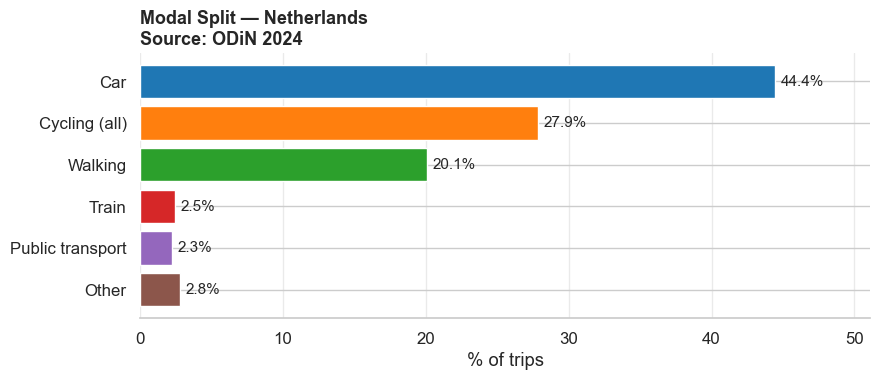

In [19]:
# Figure 1: Modal split: Overall travel mode distribution.

# Setting order for plot
order  = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']

# Weighting by weight factor
weighted = df.groupby('mode_simple')['wV'].sum()
shares = weighted / weighted.sum() * 100
shares = shares.reindex(order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(shares.index, shares.values, color=COLORS[:len(order)], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_xlabel('% of trips')
ax.set_xlim(0, shares.max() * 1.15)
ax.invert_yaxis()
ax.set_title('Modal Split — Netherlands\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.grid(axis='x', alpha=0.4)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_modal_split.png', dpi=150)
plt.show()

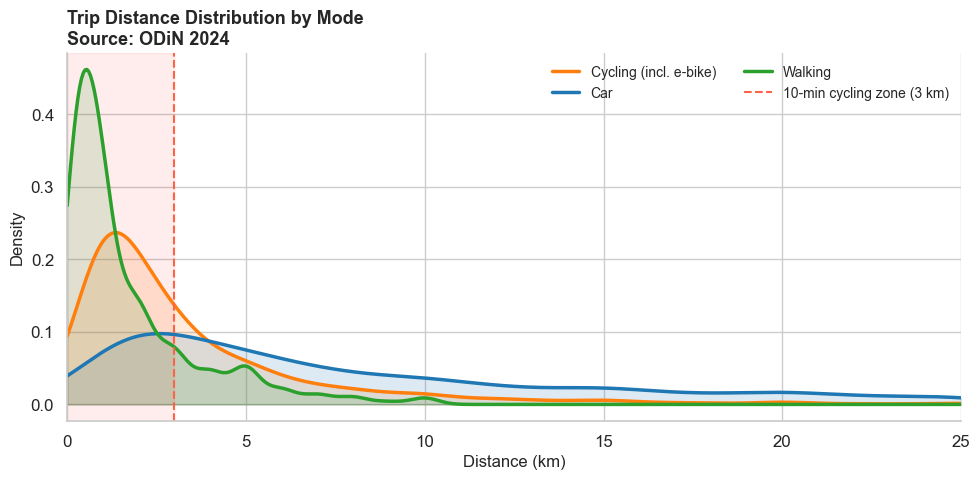

In [20]:
# Figure 2: Trip distance distribution by mode of transport
fig, ax = plt.subplots(figsize=(10, 5))
# using KDE because a raw histogram is hard to compare across modes because of the different trip counts, kde normalizes
# Setting up distances to evaluate KDE over 0 to 25km smooth curve
x = np.linspace(0, 25, 500)

# car and cycling cap at 25km walking at 10. 
for mask, lbl, col in [
    (df['is_bike'] & (df['dist_km'] <= 25), 'Cycling (incl. e-bike)', COLORS[1]),
    (df['is_car']  & (df['dist_km'] <= 25), 'Car', COLORS[0]),
    (df['is_walk'] & (df['dist_km'] <= 10), 'Walking', COLORS[2]),
]:
    # Extracting distances and dropping rows which dont have distance
    vals = df.loc[mask, 'dist_km'].dropna().values
    # Fit kernel density estimator to the distance values ( creating guassian curve)
    kde  = gaussian_kde(vals, bw_method=0.2)
    ax.plot(x, kde(x), color=col, lw=2.5, label=lbl)
    ax.fill_between(x, kde(x), alpha=0.15, color=col)

ax.axvspan(0, 3.0,  alpha=0.07, color='red')
ax.axvline(3.0,  ls='--', color='tomato', lw=1.5, label='10-min cycling zone (3 km)')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Trip Distance Distribution by Mode\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=10, ncol=2, loc='upper right')
ax.set_xlim(0, 25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_distance_dist.png', dpi=150)
plt.show()

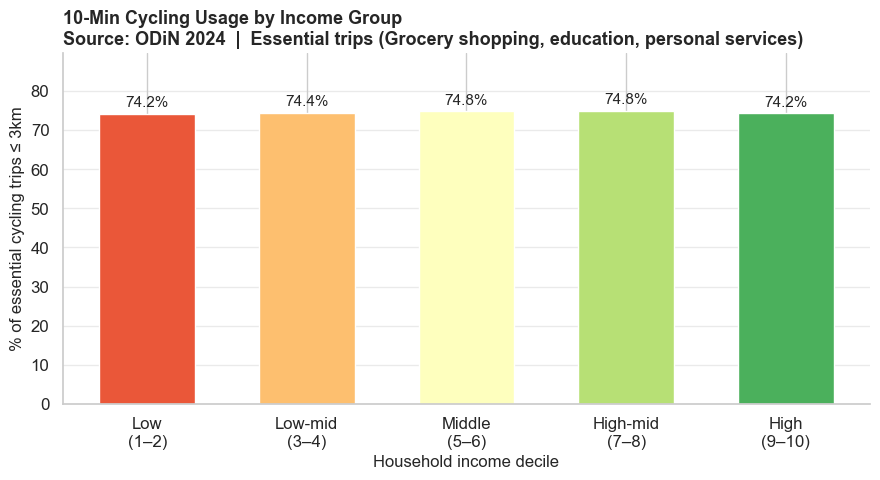

In [21]:
# Figure 3: local cycling on essential trips by income
inc_bike = (
    # Filtering by essential trips, only cycling and oonly known income groups
    df[df['is_essential'] & df['is_bike'] & (df['HHGestInkG'] <= 10)]
    .groupby('income_group', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reset_index(name='pct_bike_local')
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(inc_bike['income_group'].astype(str), inc_bike['pct_bike_local'],
              color=sns.color_palette('RdYlGn', len(inc_bike)), edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_xlabel('Household income decile', fontsize=12)
ax.set_ylabel('% of essential cycling trips ≤ 3km', fontsize=12)
ax.set_title('10-Min Cycling Usage by Income Group\n'
             'Source: ODiN 2024  |  Essential trips (Grocery shopping, education, personal services)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylim(0, inc_bike['pct_bike_local'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig3_bikeusage_income.png', dpi=150)
plt.show()

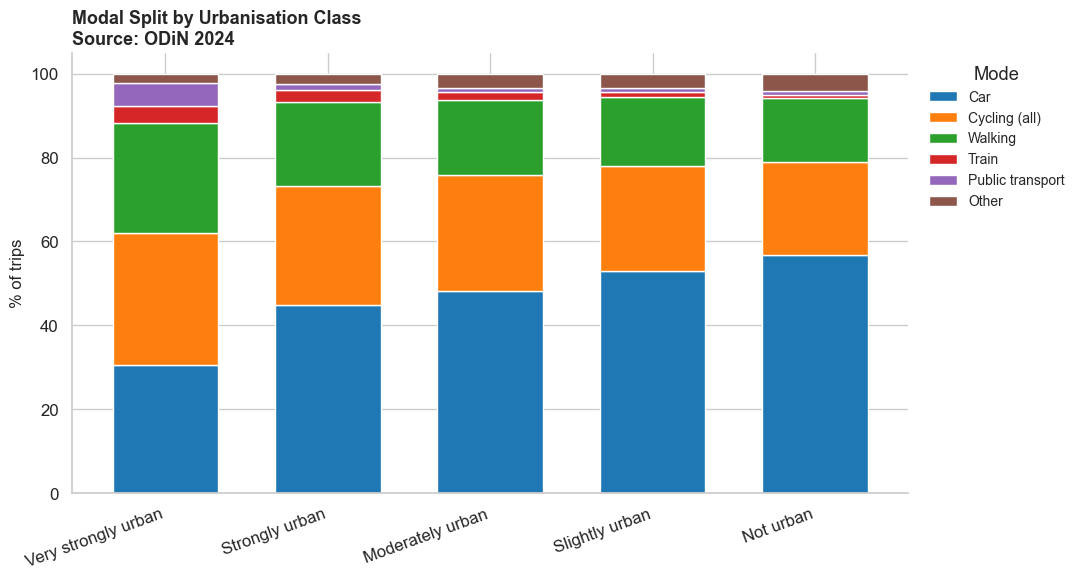

In [22]:
# Figure 4: Modal split by urbanisation
urban_mode = (
    df.groupby(['sted_label', 'mode_simple'], observed=True)
    ['wV'].sum()
    .unstack(fill_value=0)
    # row wise normalize
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

urban_order = ['Very strongly urban', 'Strongly urban', 'Moderately urban',
               'Slightly urban', 'Not urban']
col_order   = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']
urban_mode  = urban_mode.reindex(urban_order)[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
urban_mode.plot(kind='bar', stacked=True, ax=ax,
                color=COLORS[:len(col_order)], edgecolor='white', width=0.65)
ax.set_xlabel('')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Modal Split by Urbanisation Class\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(urban_order, rotation=20, ha='right')
ax.legend(title='Mode', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_modal_urbanisation.png', dpi=150)
plt.show()

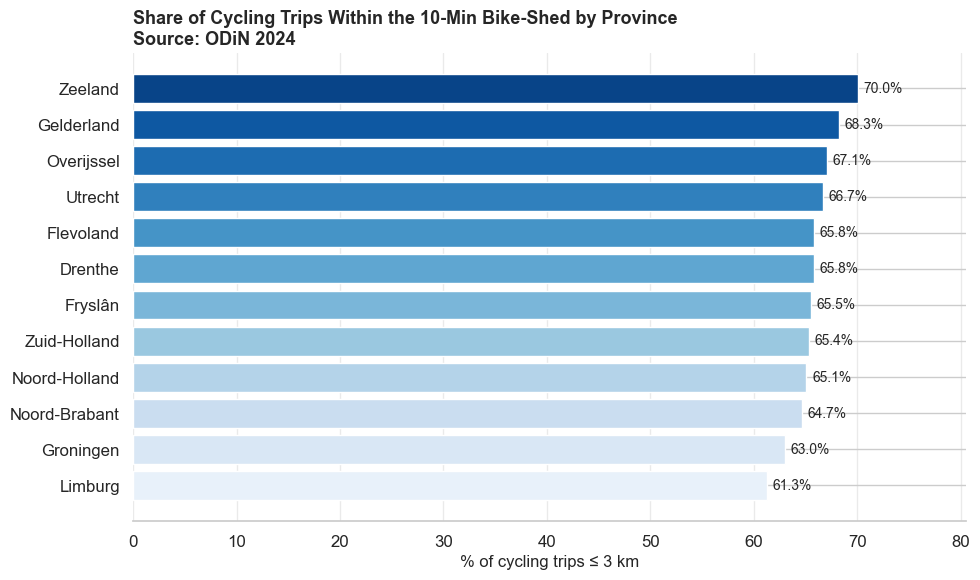

In [23]:
# Figure 5: Local cycling rate by province
prov_local = (
    df[df['is_bike']]
    .groupby('prov_label', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .sort_values(ascending=False)
    .reset_index(name='pct_within3km')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prov_local['prov_label'], prov_local['pct_within3km'],
               color=sns.color_palette('Blues_r', len(prov_local)), edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% of cycling trips ≤ 3 km', fontsize=12)
ax.invert_yaxis()
ax.set_title('Share of Cycling Trips Within the 10-Min Bike-Shed by Province\n'
             'Source: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, prov_local['pct_within3km'].max() * 1.15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fig5_local_biking_province.png', dpi=150)
plt.show()

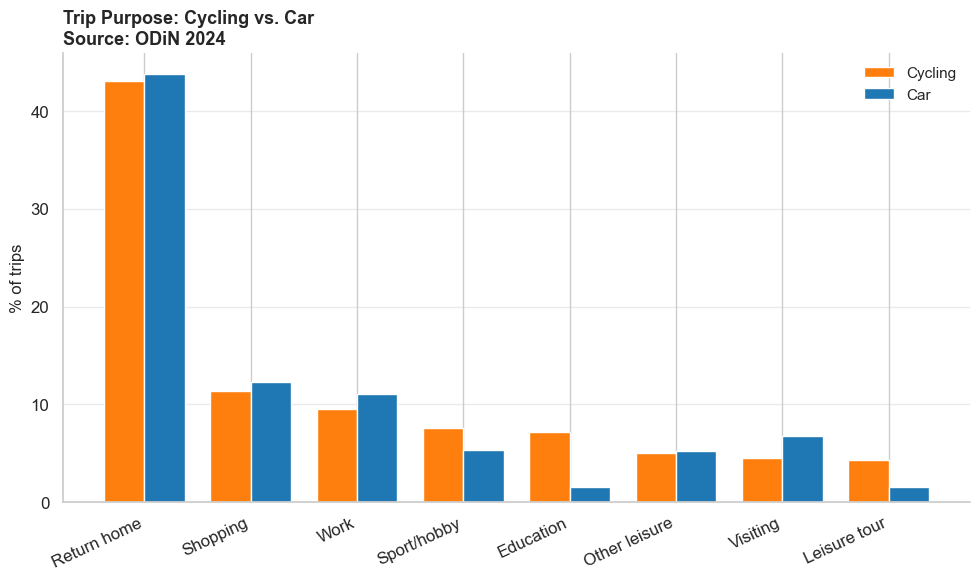

In [24]:
# Figure 6: Trip purpose bike vs car
doel_map = {1:'Return home', 2:'Work', 3:'Business visit', 4:'Professional',
            5:'Pick up/drop off person', 6:'Pick up/drop off goods',
            7:'Education', 8:'Shopping', 9:'Visiting', 10:'Leisure tour',
            11:'Sport/hobby', 12:'Other leisure', 13:'Personal services', 14:'Other'}
df['doel_label'] = df['Doel'].map(doel_map)

bike_purpose = df[df['is_bike']].groupby('doel_label')['wV'].sum()
bike_purpose = bike_purpose / bike_purpose.sum() * 100
car_purpose  = df[df['is_car']].groupby('doel_label')['wV'].sum()
car_purpose  = car_purpose / car_purpose.sum() * 100
# taking 8 biggest purposes
top_purposes = bike_purpose.nlargest(8).index
comp = pd.DataFrame({'Cycling': bike_purpose.reindex(top_purposes).fillna(0),
                     'Car':     car_purpose.reindex(top_purposes).fillna(0)})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_purposes)); w = 0.38
ax.bar(x - w/2, comp['Cycling'], width=w, label='Cycling', color=COLORS[1], edgecolor='white')
ax.bar(x + w/2, comp['Car'],     width=w, label='Car',     color=COLORS[0], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_purposes, rotation=25, ha='right')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Trip Purpose: Cycling vs. Car\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_purpose_bike_vs_car.png', dpi=150)
plt.show()

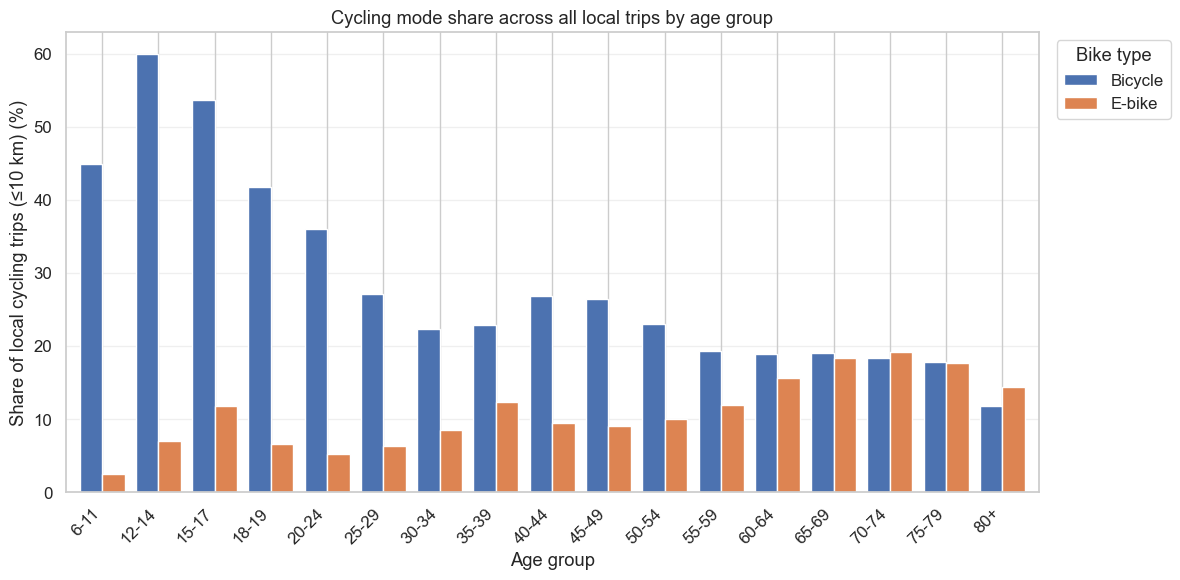

In [25]:
# Figure 7: Bike type x target age

# Labels from codebook
age_labels = {
    2: '6-11', 3: '12-14', 4: '15-17', 5: '18-19',
    6: '20-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70-74', 17: '75-79',
    18: '80+'
}

bike_labels = {
    6: 'Speed pedelec',
    7: 'E-bike',
    8: 'Bicycle'
}

df['age_group'] = df['KLeeft'].map(age_labels)
df['bike_type'] = df['Hvm'].map(bike_labels)

# all trips within 3km
all_trips = df[df['within3km']].copy()
all_trips['age_group'] = all_trips['KLeeft'].map(age_labels)

# only bike trips within 3km
bike_age = df[df['within3km'] & df['bike_type'].notna()].copy()

grouped = (
    bike_age
    .groupby(['age_group', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)

total_by_age = (
    all_trips
    .groupby('age_group', observed=True)
    ['wV'].sum()
    .reset_index(name='total')
)

grouped = grouped.merge(total_by_age, on='age_group')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = grouped.pivot(index='age_group', columns='bike_type', values='share_pct').fillna(0)

age_order = list(age_labels.values())
pivot = pivot.reindex(age_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Age group')
ax.set_ylabel('Share of local cycling trips (≤10 km) (%)')
ax.set_title('Cycling mode share across all local trips by age group')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig7_biketype_agegroup.png', dpi=150)
plt.show()

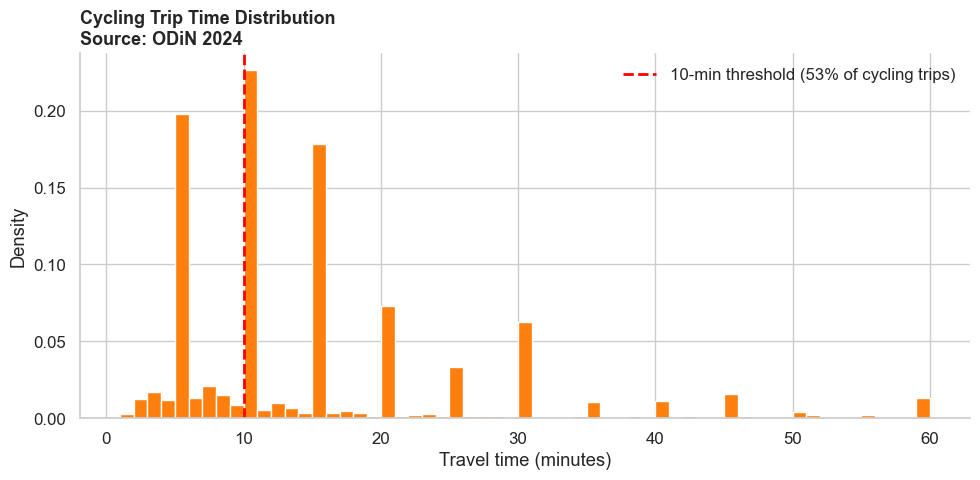

In [26]:
# Figure 8: Cycling trip time distribution
fig, ax = plt.subplots(figsize=(10, 5))
# new dataframe that is cycling and trip time
bt = df[df['is_bike'] & df['Reisduur'].between(1, 60)]
# Percentage of trips within 10 minutes
pct = np.average(bt['within10min'], weights=bt['wV']) * 100
ax.hist(bt['Reisduur'], bins=range(1, 61), weights=bt['wV'],
        color=COLORS[1], edgecolor='white', alpha=1, density=True)
# Vline at 10 min treshold
ax.axvline(10, ls='--', color='red', lw=2,
           label=f'10-min threshold ({pct:.0f}% of cycling trips)')
ax.set_xlabel('Travel time (minutes)')
ax.set_ylabel('Density')
ax.set_title('Cycling Trip Time Distribution\nSource: ODiN 2024', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_time_dist.png', dpi=150)
plt.show()

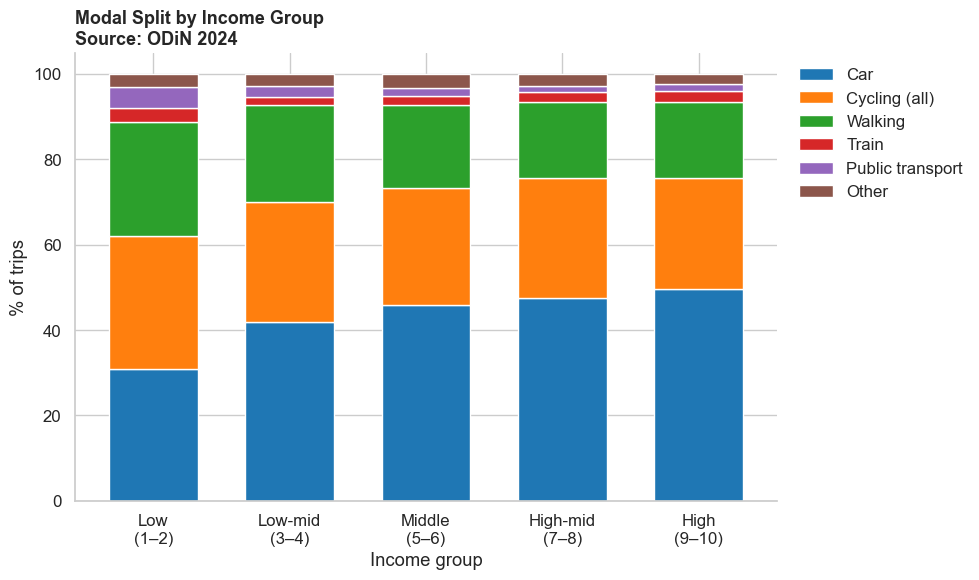

In [27]:
# Figure 9: Modal split by income group
ms_inc = (
    df[df['mode_simple'].notna() & df['HHGestInkG'].between(1, 10)]
    .groupby(['income_group', 'mode_simple'], observed=True)['wV'].sum()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)   # normalise within each income group
)[order]

fig, ax = plt.subplots(figsize=(10, 6))
ms_inc.plot(kind='bar', stacked=True, ax=ax, color=COLORS[:len(order)],
            edgecolor='white', width=0.65)
ax.set_ylabel('% of trips')
ax.set_xlabel('Income group')
ax.set_title('Modal Split by Income Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(ms_inc.index, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig9_modal_income.png', dpi=150)
plt.show()

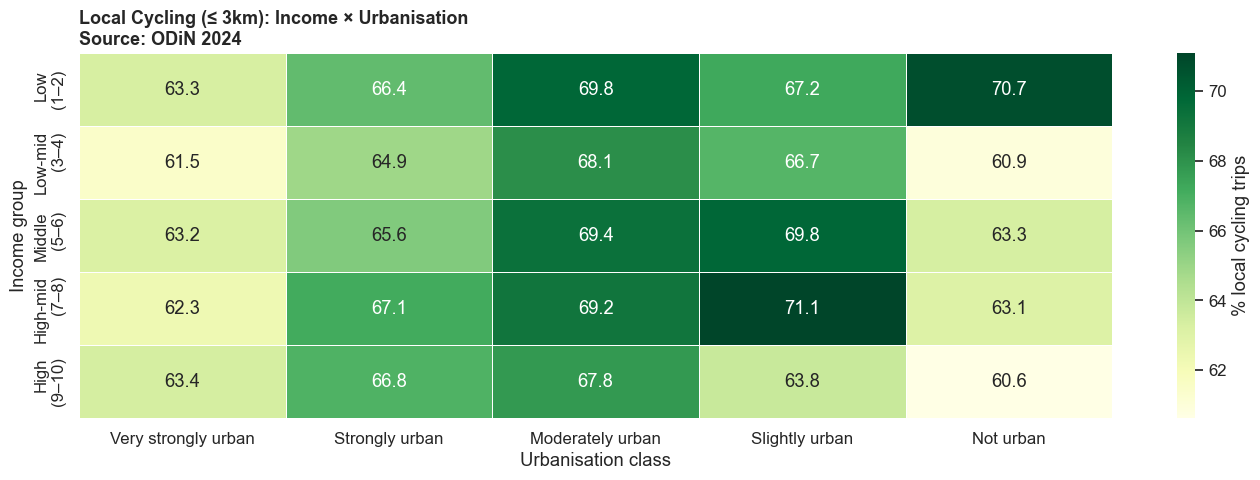

In [28]:
# Figure 10 heatmap of local cycling (within 10 min), income and urbanisation
heat = (df[df['HHGestInkG'].between(1,10) & df['sted_label'].notna() & df['is_bike']]
    .groupby(['income_group','sted_label'], observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reset_index(name='pct'))

sted_order = ['Very strongly urban','Strongly urban','Moderately urban','Slightly urban','Not urban']
pivot = heat.pivot(index='income_group', columns='sted_label', values='pct')[sted_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'% local cycling trips'})
ax.set_title('Local Cycling (≤ 3km): Income × Urbanisation\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation class')
ax.set_ylabel('Income group')
plt.tight_layout()
plt.savefig('fig10_heatmap_income_urban.png', dpi=150)
plt.show()

C:\Users\20192436\AppData\Local\Temp\ipykernel_22044\3542882149.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_order_full, rotation=45, ha='right')


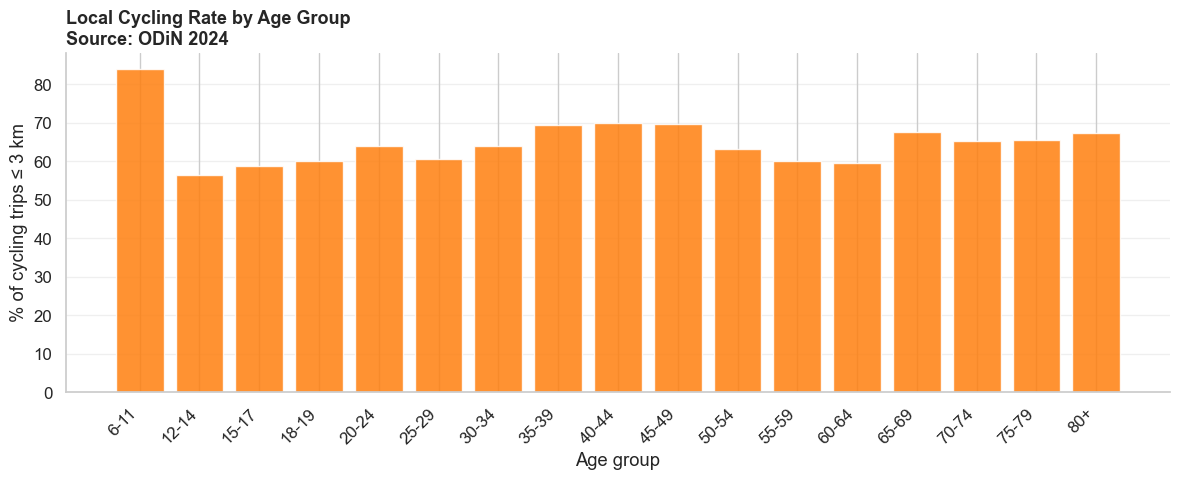

In [29]:
# Figure 11: Local cycling rate by age group
age_order_full = list(age_labels.values())
age_local = (df[df['is_bike'] & df['age_group'].notna()]
    .groupby('age_group', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reindex(age_order_full))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(age_local.index, age_local.values, color=COLORS[1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Age group')
ax.set_ylabel('% of cycling trips ≤ 3 km')
ax.set_title('Local Cycling Rate by Age Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(age_order_full, rotation=45, ha='right')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_local_cycling_age.png', dpi=150)
plt.show()

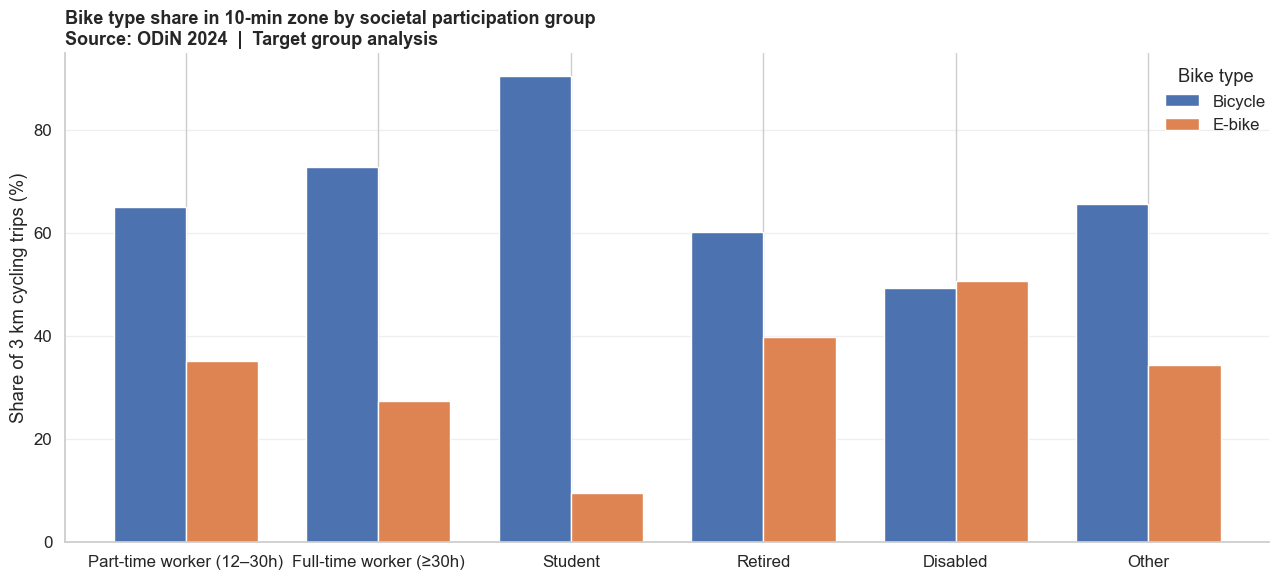

In [30]:
# Figure 12: Bike type x target group
maats_map = {
    1: 'Part-time worker (12–30h)',
    2: 'Full-time worker (≥30h)',
    3: 'Student',
    4: 'Retired',
    5: 'Disabled',
    6: 'Other'
}
maats_order = list(maats_map.values())
df['maats_label'] = df['MaatsPart_DANS24'].map(maats_map) 

# Only grouping local trips and known bike types and target group
bike_maats = df[df['within3km'] & df['bike_type'].notna() & df['maats_label'].notna()].copy()

grouped = (
    bike_maats
    .groupby(['maats_label', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)
totals = bike_maats.groupby('maats_label', observed=True)['wV'].sum().reset_index(name='total')
grouped = grouped.merge(totals, on='maats_label')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = (grouped
    .pivot(index='maats_label', columns='bike_type', values='share_pct')
    .fillna(0)
    .reindex(maats_order)
)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_ylabel('Share of 3 km cycling trips (%)')
ax.set_xlabel('')
ax.set_title('Bike type share in 10-min zone by societal participation group\n'
             'Source: ODiN 2024  |  Target group analysis',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(maats_order, rotation=0, ha='center')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig12_biketype_participation.png', dpi=150)
plt.show()

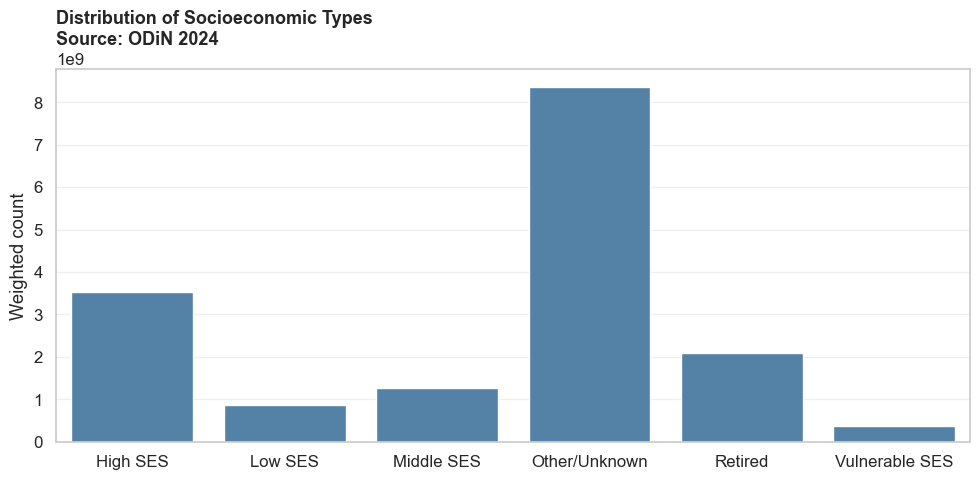

In [31]:
# Education
edu_map = {
    1: 'Low education',
    2: 'Medium education',
    3: 'High education',
    4: None,
    5: None
}
df['edu_label'] = df['Opleiding_DANS24'].map(edu_map)

# Participation
maats_map = {
    1: 'Part-time worker',
    2: 'Full-time worker',
    3: 'Student',
    4: 'Disabled',
    5: 'Retired',
    6: 'Other'
}
df['maats_label'] = df['MaatsPart_DANS24'].map(maats_map)

df['income_group'] = pd.cut(
    df['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low (1–2)', 'Low-mid (3–4)', 'Middle (5–6)',
            'High-mid (7–8)', 'High (9–10)']
)


def classify_ses(row):
    edu = row['edu_label']
    inc = row['income_group']     # <-- use the label
    part = row['maats_label']
    
    if edu == 'High education' and inc in ['High (9–10)', 'High-mid (7–8)'] and part in ['Full-time worker', 'Part-time worker']:
        return 'High SES'
    if edu == 'Medium education' and inc in ['Middle (5–6)', 'Low-mid (3–4)'] and part in ['Full-time worker', 'Part-time worker', 'Student']:
        return 'Middle SES'
    if edu == 'Low education' and inc in ['Low (1–2)', 'Low-mid (3–4)']:
        return 'Low SES'
    if part == 'Disabled':
        return 'Vulnerable SES'
    if part == 'Retired':
        return 'Retired'
    return 'Other/Unknown'


df['SES_type'] = df.apply(classify_ses, axis=1)


ses_counts = (
    df[df['SES_type'].notna()]
    .groupby('SES_type')['FactorV']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=ses_counts, x='SES_type', y='FactorV', color='steelblue')
plt.title('Distribution of Socioeconomic Types\nSource: ODiN 2024', fontsize=13, fontweight='bold', loc='left')
plt.ylabel('Weighted count')
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

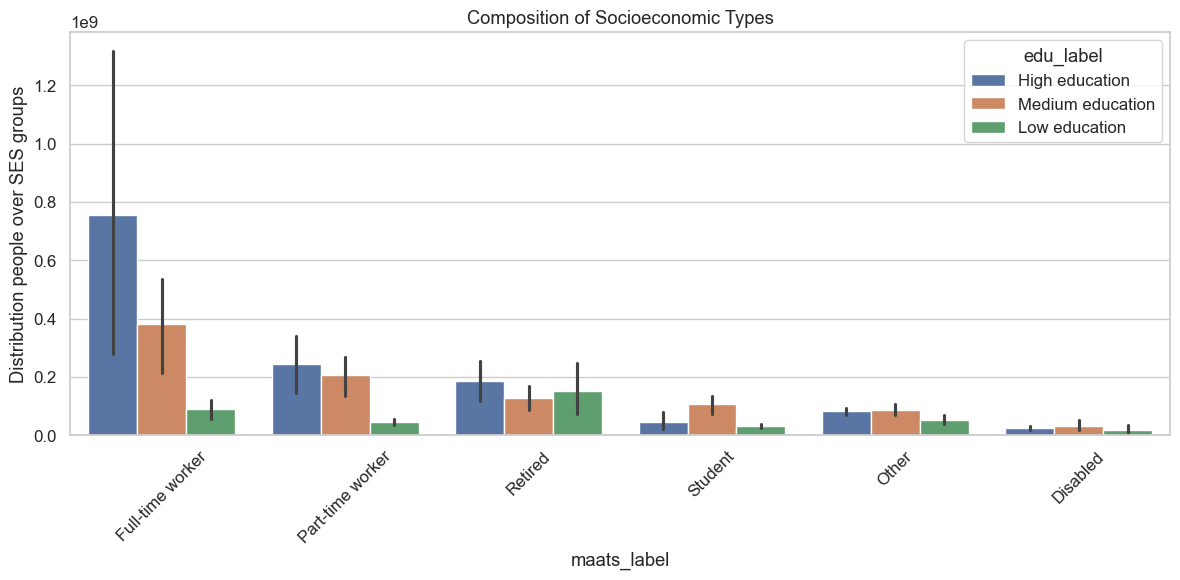

In [32]:
ses_all = (
    df
    .groupby(['edu_label', 'income_group', 'maats_label'])['FactorV']
    .sum()
    .reset_index()
    .sort_values('FactorV', ascending=False)
)


plt.figure(figsize=(12,6))
sns.barplot(
    data=ses_all,
    x='maats_label',
    y='FactorV',
    hue='edu_label'
)
plt.title('Composition of Socioeconomic Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel("Distribution people over SES groups") #FactorV corrects for: sampling bias, non-response, demographic imbalance, regional difference
plt.show()

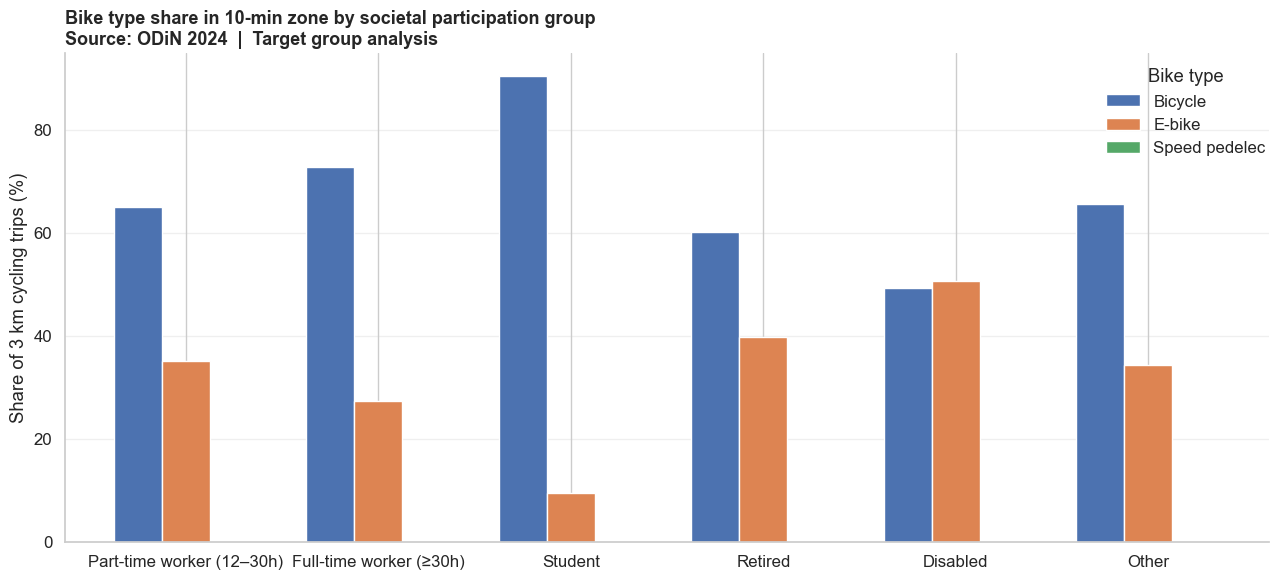

In [33]:
df_trips = odin_2024.copy()
df_trips['dist_km']      = df_trips['AfstV'] / 10
# KHvm is bike usage
df_trips['is_bike']      = df_trips['KHvm'] == 5
df_trips['is_car']       = df_trips['Hvm'] == 1
df_trips['is_walk']      = df_trips['Hvm'] == 9
# add within 3 km bool
df_trips['within3km']    = df_trips['dist_km'] <= 3.0

df_trips['dist_km']      = df_trips['AfstV'] / 10
# KHvm is bike usage
df_trips['is_bike']      = df_trips['KHvm'] == 5
df_trips['is_car']       = df_trips['Hvm'] == 1
df_trips['is_walk']      = df_trips['Hvm'] == 9
# add within 3 km bool
df_trips['within3km']    = df_trips['dist_km'] <= 3.0
# Same for within 10 minutes
df_trips['within10min'] = df_trips['Reisduur'] <= 10
# Essentials are (according to smartwayz): education, grocery shopping, services
df_trips['is_essential'] = df_trips['Doel'].isin([7, 8, 13])
# trip level weight we should always use this factor to get representative trip shares
df_trips['wV'] = pd.to_numeric(df_trips['FactorV'], errors='coerce').fillna(0)

#Keeping only regular trips
df_trips = df_trips[df_trips['Verpl'] == 1].copy()

# # Mode labels (from Hvm) for plots
# mode_map = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
#             6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
#             11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
# df_trips['mode_label'] = df_trips['Hvm'].map(mode_map)

# # Simplified modes to 6 groups for cleaner charts
# simplify = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
#             'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
#             'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
# df_trips['mode_simple'] = df_trips['mode_label'].replace(simplify)

# # HHGestInkG is standardised household income decile (1=lowest, 10 = highest)
# df_trips['income_group'] = pd.cut(df_trips['HHGestInkG'],
#     bins=[0, 2, 4, 6, 8, 10],
#     labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
#             'High-mid\n(7–8)', 'High\n(9–10)'])

# Bike type labels (from Hvm for bikes: 6=Speed pedelec, 7=E-bike, 8=Bicycle)
bike_labels = {6: 'Speed pedelec', 7: 'E-bike', 8: 'Bicycle'}
df_trips['bike_type'] = df_trips['Hvm'].map(bike_labels)

maats_map = {
    1: 'Part-time worker (12–30h)',
    2: 'Full-time worker (≥30h)',
    3: 'Student',
    4: 'Retired',
    5: 'Disabled',
    6: 'Other'
}
maats_order = list(maats_map.values())
df_trips['maats_label'] = df_trips['MaatsPart_DANS24'].map(maats_map) 


bike_maats = df_trips[
    df_trips['within3km'] &
    df_trips['bike_type'].notna() &
    df_trips['maats_label'].notna()
]

# --- Weighted counts per group ---
grouped = (
    bike_maats
    .groupby(['maats_label', 'bike_type'], observed=True)['wV']
    .sum()
    .reset_index(name='count')
)

# --- Total weighted trips per participation group ---
totals = (
    bike_maats
    .groupby('maats_label', observed=True)['wV']
    .sum()
    .reset_index(name='total')
)

# --- Merge + compute share ---
grouped = grouped.merge(totals, on='maats_label')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

# --- Ensure all bike types appear as columns ---
all_bike_types = sorted(df_trips['bike_type'].dropna().unique())

pivot = (
    grouped
    .pivot(index='maats_label', columns='bike_type', values='share_pct')
    .reindex(maats_order)          # correct order of rows
    .reindex(columns=all_bike_types)  # consistent bike type order
    .fillna(0)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')

ax.set_ylabel('Share of 3 km cycling trips (%)')
ax.set_xlabel('')
ax.set_title(
    'Bike type share in 10-min zone by societal participation group\n'
    'Source: ODiN 2024  |  Target group analysis',
    fontsize=13, fontweight='bold', loc='left'
)

ax.set_xticklabels(maats_order, rotation=0, ha='center')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [34]:
# Normalise buurt keys
def to_buurt8(code):
    return str(code).strip().lstrip('BU').lstrip('bu').zfill(8)

cbs['buurt_key']            = cbs['gwb_code_8'].astype(str).str.zfill(8)
voorzieningen['buurt_key']  = voorzieningen['buurtcode'].apply(to_buurt8)
pc6hnr2025['buurt_key']     = pc6hnr2025['Buurt2025'].apply(to_buurt8)
buurt_to_buurt['ori_key']   = buurt_to_buurt['buurt_ori_id'].apply(to_buurt8)
buurt_to_buurt['dest_key']  = buurt_to_buurt['buurt_id'].apply(to_buurt8)

# Map Buurt to  PC4 
pc6hnr2025['PC4'] = pc6hnr2025['PC6'].str[:4].astype(int)

# Count how many addresses exist for each Buurt-PC4 combination
buurt_pc4_counts = pc6hnr2025.groupby(['buurt_key', 'PC4']).size().reset_index(name='address_count')

# Keep the PC4 that holds the most addresses for each Buurt
buurt_to_dominant_pc4 = (
    buurt_pc4_counts
    .sort_values('address_count', ascending=False)
    .drop_duplicates('buurt_key')[['buurt_key', 'PC4']]
)

# Compute ODiN Behavior at PC4 Level & Map to Buurt
odin_2024['VertPC_PRAM'] = pd.to_numeric(odin_2024['VertPC_PRAM'], errors='coerce')

# Filter strictly for CYCLING (5) and ESSENTIAL trips (7, 8, 13)
essential_cycling = odin_2024[
    (odin_2024['KHvm'] == 5) & 
    (odin_2024['Doel'].isin([7, 8, 13]))
].copy()

# 3km threshold (AfstV is in hectometres)
essential_cycling['within_3km'] = (essential_cycling['AfstV'] / 10) <= 3

def weighted_usage(x):
    if x['FactorV'].sum() == 0: return np.nan
    return np.average(x['within_3km'], weights=x['FactorV']) * 100

# Aggregate at the PC4 level
odin_pc4 = (
    essential_cycling
    .groupby('VertPC_PRAM')
    .apply(lambda x: pd.Series({
        'pct_within_3km':   weighted_usage(x),
        'mean_dist_km':     np.average(x['AfstV'] / 10, weights=x['FactorV']) if x['FactorV'].sum() > 0 else np.nan,
        'n_trips_weighted': x['FactorV'].sum()
    }))
    .reset_index()
    .rename(columns={'VertPC_PRAM': 'PC4'})
)

# Project PC4 behavior down to the specific Buurten
odin_buurt = buurt_to_dominant_pc4.merge(odin_pc4, on='PC4', how='left')


# Preserve ammenity Density 
ammenity_cols = [c for c in voorzieningen.columns if c not in ('buurtcode', 'buurt_key', 'aantal_drinkwaterpunt')]

# Convert categorical '2+' into integers to keep density counts
for col in ammenity_cols:
    voorzieningen[col] = voorzieningen[col].replace({'2+': 1}) # I replaced it with 1, so now it either has a ammenity close by or not
    voorzieningen[col] = pd.to_numeric(voorzieningen[col], errors='coerce').fillna(0).astype(int)

#Define isochrone thresholds 3000 meters for bike, ebike is 25% faster so 3750m and walking is 5km/h so 1250 for 15 minutes
bike_direct_dist = np.where(
    buurt_to_buurt['bike_2025_smart_detour_factor'] > 0,
    buurt_to_buurt['bike_2025_smart_distance'] / buurt_to_buurt['bike_2025_smart_detour_factor'],
    np.nan
)
ebike_direct_dist = np.where(
    buurt_to_buurt['ebike_2025_smart_detour_factor'] > 0,
    buurt_to_buurt['ebike_2025_smart_distance'] / buurt_to_buurt['ebike_2025_smart_detour_factor'],
    np.nan
)
walk_direct_dist = np.where(
    buurt_to_buurt['walk_2025_detour_factor'] > 0,
    buurt_to_buurt['walk_2025_distance'] / buurt_to_buurt['walk_2025_detour_factor'],
    np.nan
)

buurt_to_buurt['bike_10min']         = buurt_to_buurt['bike_2025_smart_distance']  <= 3000
buurt_to_buurt['ebike_10min']        = buurt_to_buurt['ebike_2025_smart_distance'] <= 3750
buurt_to_buurt['walk_15min']         = buurt_to_buurt['walk_2025_distance']        <= 1250
buurt_to_buurt['bike_10min_direct']  = bike_direct_dist <= 3000
buurt_to_buurt['ebike_10min_direct'] = ebike_direct_dist <= 3750
buurt_to_buurt['walk_15min_direct']  = walk_direct_dist <= 1250

# Average detour factor per origin neighbourhood
origin_detour = (
    buurt_to_buurt
    .groupby('ori_key', observed=True)[
        ['bike_2025_smart_detour_factor', 'ebike_2025_smart_detour_factor']
    ]
    .mean()
    .reset_index()
    .rename(columns={
        'bike_2025_smart_detour_factor': 'bike_detour_rate',
        'ebike_2025_smart_detour_factor': 'ebike_detour_rate'
    })
)
origin_detour['buurt_key'] = origin_detour['ori_key']

# Compute raw ammenity counts within each isochrone
def compute_access(b2b_filtered, label):
    return (
        b2b_filtered[['ori_key', 'dest_key']]
        .merge(voorzieningen[['buurt_key'] + ammenity_cols], left_on='dest_key', right_on='buurt_key', how='left')
        .groupby('ori_key')[ammenity_cols]
        .sum()  # This now sums total volume of amenities, not just buurten
        .reset_index()
        .rename(columns={c: f'{label}_{c}' for c in ammenity_cols})
        .rename(columns={'ori_key': 'buurt_key'})
    )

access_bike  = compute_access(buurt_to_buurt[buurt_to_buurt['bike_10min']],  'bike10')
access_ebike = compute_access(buurt_to_buurt[buurt_to_buurt['ebike_10min']], 'ebike10')
access_walk  = compute_access(buurt_to_buurt[buurt_to_buurt['walk_15min']],  'walk15')
access_bike_direct  = compute_access(buurt_to_buurt[buurt_to_buurt['bike_10min_direct']],  'bike10_direct')
access_ebike_direct = compute_access(buurt_to_buurt[buurt_to_buurt['ebike_10min_direct']], 'ebike10_direct')
access_walk_direct  = compute_access(buurt_to_buurt[buurt_to_buurt['walk_15min_direct']],  'walk15_direct')

# Compute  score
for acc_df, label in [
    (access_bike, 'bike10'), (access_ebike, 'ebike10'), (access_walk, 'walk15'),
    (access_bike_direct, 'bike10_direct'), (access_ebike_direct, 'ebike10_direct'), (access_walk_direct, 'walk15_direct')
]:
    fac_cols = [c for c in acc_df.columns if c.startswith(label + '_klasse')]
    # _score = number of *unique ammenity types* reached (at least 1)
    acc_df[f'{label}_score']            = (acc_df[fac_cols] >= 1).sum(axis=1)
    # _total_facilities = massive raw sum of all facilities reached
    acc_df[f'{label}_total_facilities'] = acc_df[fac_cols].sum(axis=1)

# Compute WEIGHTED access index
ammenity_WEIGHTS = {
    'klasse_supermarkt':            0.18,
    'klasse_huisarts':              0.14,
    'klasse_basisschool':           0.13,
    'klasse_ziekenhuis':            0.10,
    'klasse_apotheek':              0.07,
    'klasse_voortgezet_onderwijs':  0.07,
    'klasse_bushalte':              0.06,
    'klasse_treinstation':          0.05,
    'klasse_kinderopvang':          0.03,
    'klasse_horeca':                0.05,
    'klasse_restaurant':            0.04,
    'klasse_sportterrein':          0.04,
    'klasse_fastfood':              0.02,
    'klasse_kledingwinkel':         0.02,
}

def compute_weighted_score(acc_df, label, weights):
    score = pd.Series(0.0, index=acc_df.index)
    for fac, w in weights.items():
        col = f'{label}_{fac}'
        if col in acc_df.columns:
            pct_rank = acc_df[col].rank(pct=True) * 100
            score += pct_rank * w
    acc_df[f'{label}_weighted_score'] = score
    return acc_df

access_bike  = compute_weighted_score(access_bike,  'bike10',  ammenity_WEIGHTS)
access_ebike = compute_weighted_score(access_ebike, 'ebike10',  ammenity_WEIGHTS)
access_walk  = compute_weighted_score(access_walk,  'walk15',  ammenity_WEIGHTS)
access_bike_direct  = compute_weighted_score(access_bike_direct,  'bike10_direct',  ammenity_WEIGHTS)
access_ebike_direct = compute_weighted_score(access_ebike_direct, 'ebike10_direct',  ammenity_WEIGHTS)
access_walk_direct  = compute_weighted_score(access_walk_direct,  'walk15_direct',  ammenity_WEIGHTS)

# Merging all access metrics 
access_all = (
    access_bike
    .merge(access_ebike, on='buurt_key', how='outer')
    .merge(access_walk,  on='buurt_key', how='outer')
    .merge(access_bike_direct,  on='buurt_key', how='outer')
    .merge(access_ebike_direct, on='buurt_key', how='outer')
    .merge(access_walk_direct,  on='buurt_key', how='outer')
)

# Filter CBS to buurt level only
cbs_buurt = cbs[cbs['recs'] == 'Buurt'].copy()

# Build main DataFrame 
df = (
    voorzieningen
    .merge(cbs_buurt,  on='buurt_key', how='left')
    .merge(access_all, on='buurt_key', how='left')
    .merge(odin_buurt, on='buurt_key', how='left')
    .merge(origin_detour[['buurt_key', 'bike_detour_rate', 'ebike_detour_rate']], on='buurt_key', how='left')
)

print(f"Master df shape: {df.shape}")
print(f"Buurten with usage data: {df['pct_within_3km'].notna().sum()}")
print(f"Buurten with access data: {df['bike10_weighted_score'].notna().sum()}")

Master df shape: (14515, 249)
Buurten with usage data: 10832
Buurten with access data: 14189


In [35]:
df.head()

,buurtcode,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,...,walk15_direct_klasse_ziekenhuis,walk15_direct_score,walk15_direct_total_facilities,walk15_direct_weighted_score,PC4,pct_within_3km,mean_dist_km,n_trips_weighted,bike_detour_rate,ebike_detour_rate
0,BU00140000,0,1,1,1,1,1,1,1,1,...,1.0,12.0,90.0,83.994543,9712.0,92.941537,1.371408,1.429395e+06,1.150095,1.147059
1,BU00140001,1,0,1,1,1,1,1,1,1,...,0.0,12.0,118.0,85.875782,9711.0,68.759720,2.509376,1.287488e+06,1.147730,1.145661
2,BU00140002,0,1,1,1,1,1,1,1,1,...,1.0,12.0,92.0,85.386430,9711.0,68.759720,2.509376,1.287488e+06,1.169185,1.164483
3,BU00140003,0,0,1,1,1,0,1,1,1,...,1.0,13.0,109.0,90.584338,9718.0,96.304384,1.783452,1.248661e+06,1.145252,1.143918
4,BU00140004,0,0,1,0,1,0,1,0,1,...,1.0,12.0,83.0,83.424286,9717.0,66.477210,2.663044,1.095341e+06,1.159682,1.156298


In [36]:

df_access = df[
    (df['a_inw'] >= 200) & 
    (df['bike10_weighted_score'].notna())
].copy()

# Add your Affluence Decile to df_access
df_access['income_decile'] = pd.qcut(
    pd.to_numeric(df_access['g_ink_pi'], errors='coerce'), 
    q=5, 
    labels=['Low', 'Low-mid', 'Middle', 'High-mid', 'High']
)
df_access['stedelijkheid_label'] = df_access['ste_mvs'].map({
    1: 'Very urban', 2: 'Urban', 3: 'Moderately urban', 4: 'Slightly urban', 5: 'Rural'
})

# 2. Paired Data (Intersected coverage: Use ONLY when plotting Usage)
df_paired = df_access[df_access['pct_within_3km'].notna()].copy()

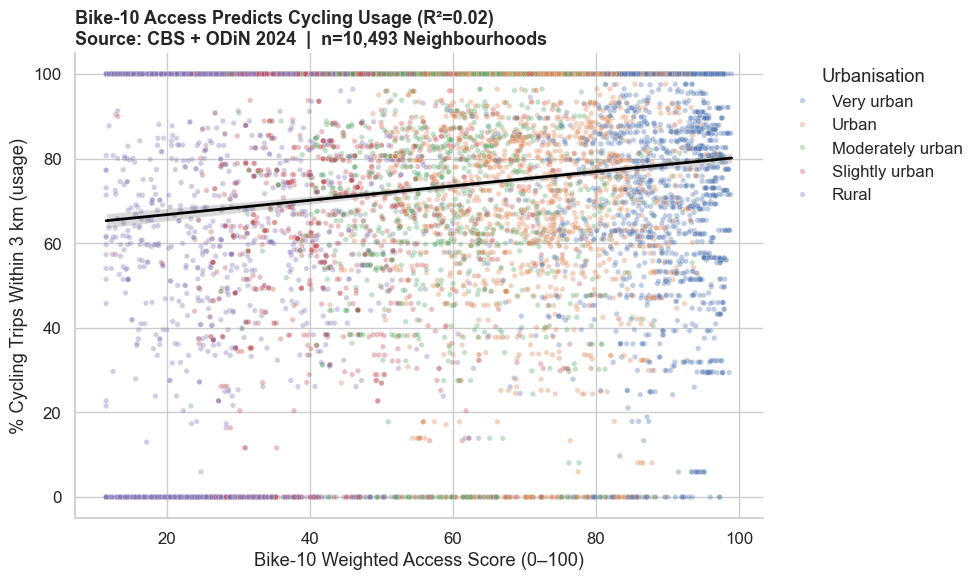

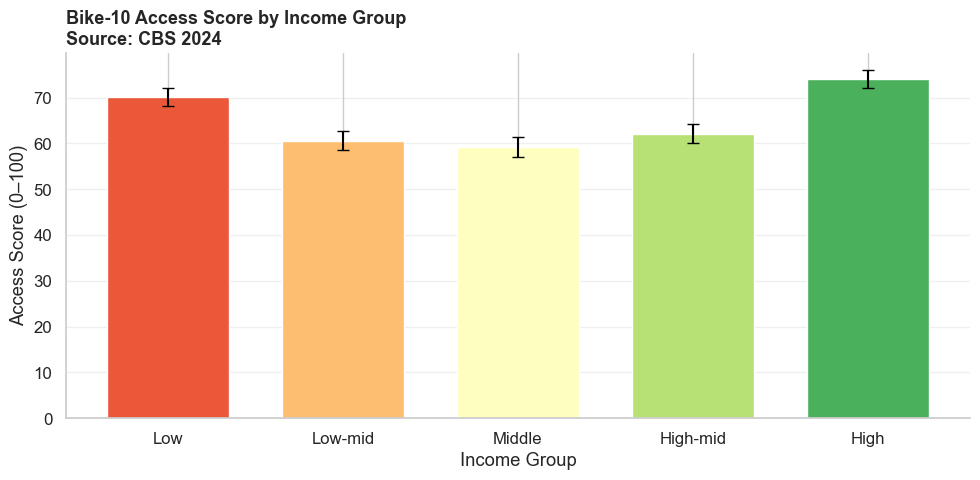

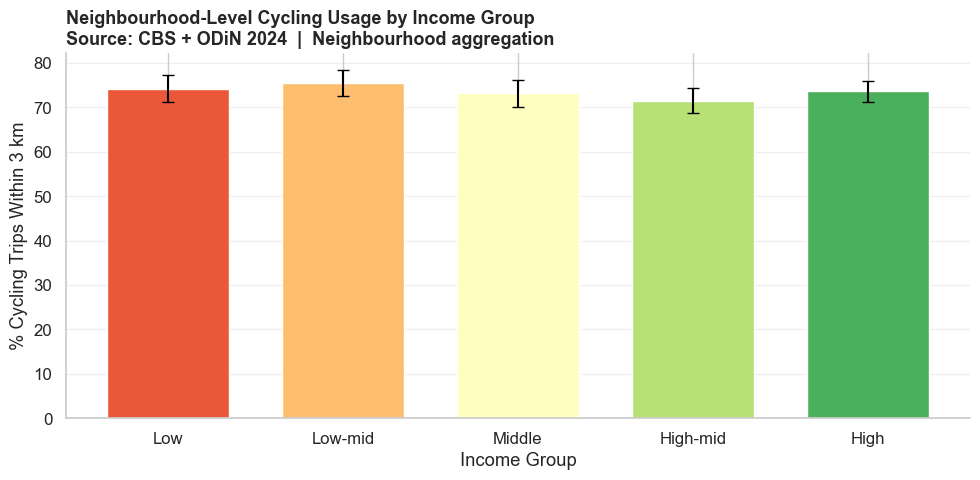

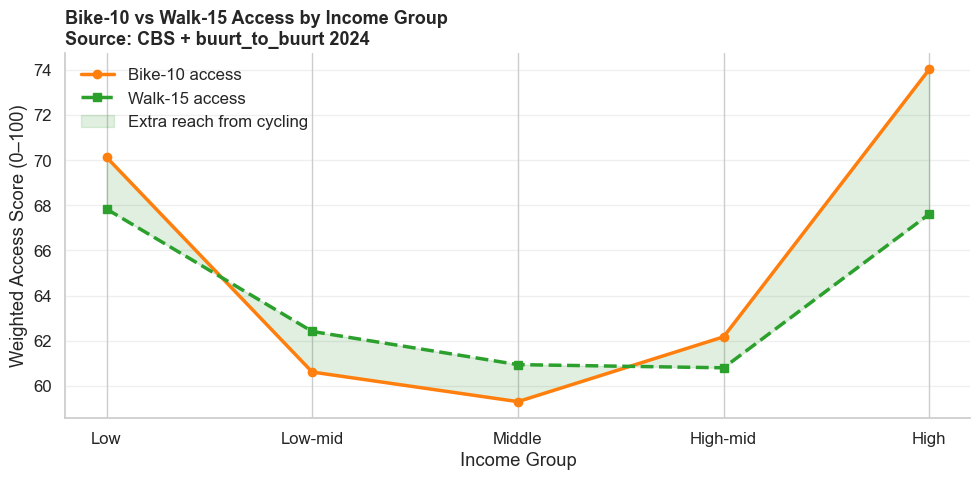

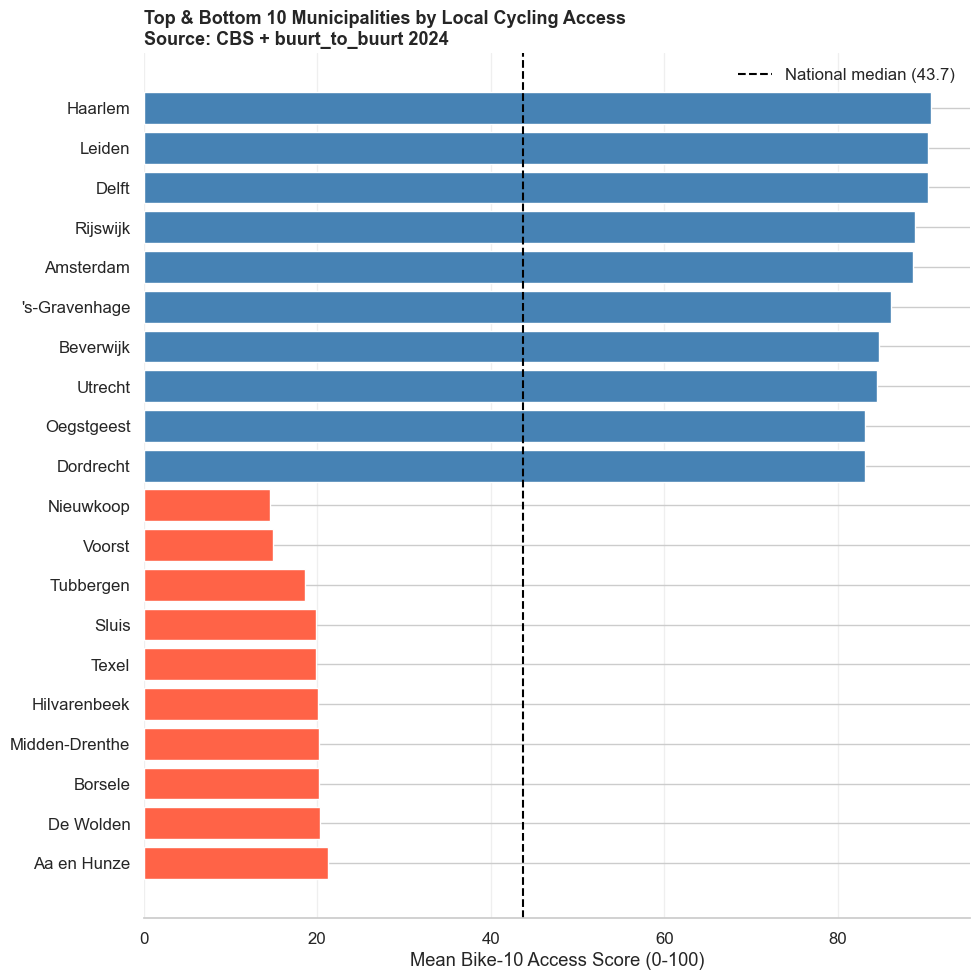

In [39]:
from scipy.stats import pearsonr

# Fig 13: Access predicts cycling usage
r2 = pearsonr(df_paired['bike10_weighted_score'], df_paired['pct_within_3km'])[0]**2

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_paired, x='bike10_weighted_score', y='pct_within_3km',
                hue='stedelijkheid_label', alpha=0.35, s=15, ax=ax,
                hue_order=['Very urban','Urban','Moderately urban','Slightly urban','Rural'])
sns.regplot(data=df_access, x='bike10_weighted_score', y='pct_within_3km',
            scatter=False, lowess=False, color='black', line_kws={'lw':2}, ax=ax)
ax.set_title(f'Bike-10 Access Predicts Cycling Usage (R²={r2:.2f})\nSource: CBS + ODiN 2024  |  n={len(df_access):,} Neighbourhoods',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Bike-10 Weighted Access Score (0–100)')
ax.set_ylabel('% Cycling Trips Within 3 km (usage)')
ax.legend(title='Urbanisation', bbox_to_anchor=(1.01,1), frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig13_access_usage_scatter.png', dpi=150)
plt.show()

# Fig 14: Bike-10 access by income decile
acc_dec = (df_access.groupby('income_decile', observed=True)['bike10_weighted_score']
           .agg(['mean','sem']).reset_index())
acc_dec['ci95'] = acc_dec['sem'] * 1.96


fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(acc_dec['income_decile'], acc_dec['mean'],
              color=sns.color_palette('RdYlGn', len(acc_dec)), edgecolor='white', width=0.7)
ax.errorbar(acc_dec['income_decile'], acc_dec['mean'],
            yerr=acc_dec['ci95'], fmt='none', color='black', capsize=4)
ax.set_title('Bike-10 Access Score by Income Group \nSource: CBS 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('Access Score (0–100)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig14_access_by_income.png', dpi=150)
plt.show()

# Fig 15: Neighbourhood-level cycling usage by income decile
use_dec = (df_paired.groupby('income_decile', observed=True)['pct_within_3km']
           .agg(['mean','sem']).reset_index())
use_dec['ci95'] = use_dec['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(use_dec['income_decile'], use_dec['mean'],
              color=sns.color_palette('RdYlGn', len(use_dec)), edgecolor='white', width=0.7)
ax.errorbar(use_dec['income_decile'], use_dec['mean'],
            yerr=use_dec['ci95'], fmt='none', color='black', capsize=4)
ax.set_title('Neighbourhood-Level Cycling Usage by Income Group\nSource: CBS + ODiN 2024  |  Neighbourhood aggregation',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('% Cycling Trips Within 3 km')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig15_usage_by_income_buurt.png', dpi=150)
plt.show()

# Fig 16: Bike-10 vs Walk-15 access by income 
reach = (df_access.groupby('income_decile', observed=True)
         .agg(bike10=('bike10_weighted_score','mean'),
              walk15=('walk15_weighted_score','mean'))
         .reset_index())


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(reach['income_decile'], reach['bike10'], marker='o', color=COLORS[1],
        lw=2.5, label='Bike-10 access')
ax.plot(reach['income_decile'], reach['walk15'], marker='s', color=COLORS[2],
        lw=2.5, linestyle='--', label='Walk-15 access')
ax.fill_between(reach['income_decile'], reach['walk15'], reach['bike10'],
                alpha=0.12, color='green', label='Extra reach from cycling')
ax.set_title('Bike-10 vs Walk-15 Access by Income Group \nSource: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('Weighted Access Score (0–100)')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig16_bike_vs_walk_access.png', dpi=150)
plt.show()

# Fig 17: Top/bottom 10 municipalities by bike-10 access 
mun = (df_access.groupby('gm_naam', observed=True)['bike10_weighted_score']
       .mean().sort_values())
bottom10 = mun.head(10)
top10    = mun.tail(10).sort_values(ascending=False)
ranked   = pd.concat([top10, bottom10])
colors   = ['steelblue']*10 + ['tomato']*10

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(ranked.index, ranked.values, color=colors, edgecolor='white')
ax.axvline(mun.median(), ls='--', color='black', lw=1.5, label=f'National median ({mun.median():.1f})')
ax.set_xlabel('Mean Bike-10 Access Score (0-100)')
ax.set_title('Top & Bottom 10 Municipalities by Local Cycling Access \nSource: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig17_municipality_ranking.png', dpi=150)
plt.show()

C:\Users\20192436\AppData\Local\Temp\ipykernel_22044\461399323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_access, x='stedelijkheid_label', y='bike10_weighted_score',


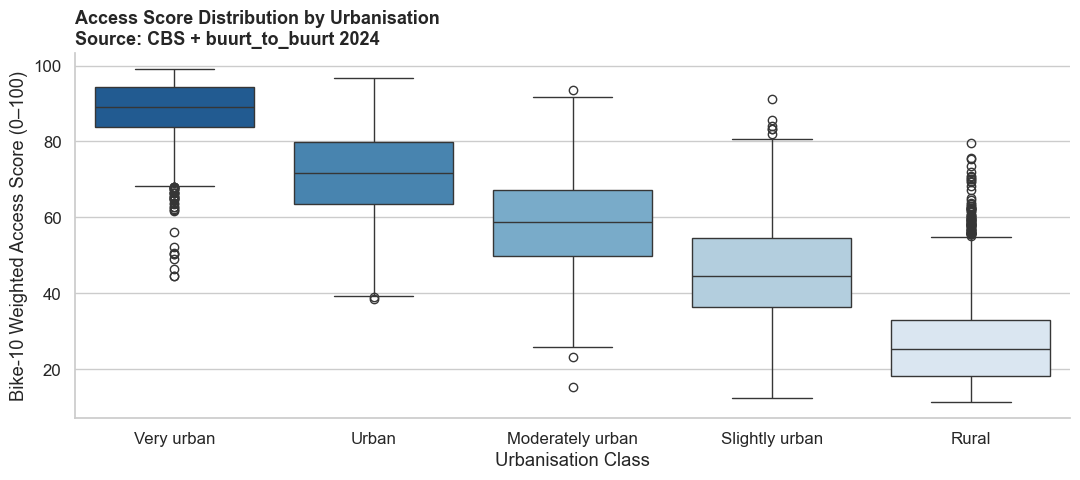

In [40]:
fig, ax = plt.subplots(figsize=(11, 5))
urban_order = ['Very urban', 'Urban', 'Moderately urban', 'Slightly urban', 'Rural']
sns.boxplot(data=df_access, x='stedelijkheid_label', y='bike10_weighted_score',
            order=urban_order, palette='Blues_r', ax=ax)
ax.set_title('Access Score Distribution by Urbanisation\n'
             'Source: CBS + buurt_to_buurt 2024', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation Class')
ax.set_ylabel('Bike-10 Weighted Access Score (0–100)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig18_access_boxplot_urban.png', dpi=150)

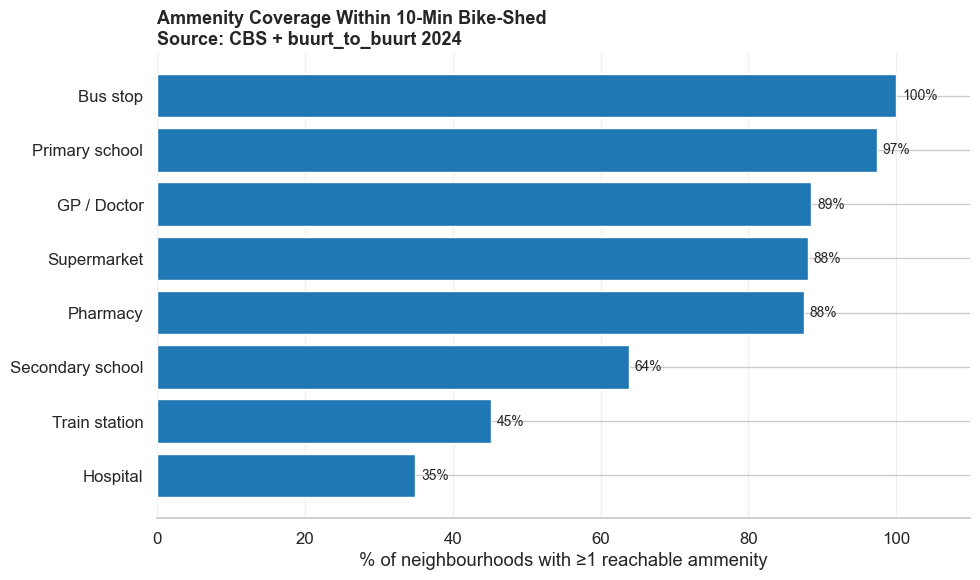

In [41]:
fac_labels = {
    'bike10_klasse_supermarkt': 'Supermarket',
    'bike10_klasse_huisarts': 'GP / Doctor',
    'bike10_klasse_basisschool': 'Primary school',
    'bike10_klasse_ziekenhuis': 'Hospital',
    'bike10_klasse_apotheek': 'Pharmacy',
    'bike10_klasse_voortgezet_onderwijs': 'Secondary school',
    'bike10_klasse_bushalte': 'Bus stop',
    'bike10_klasse_treinstation': 'Train station',
}
coverage = {lbl: (df_access[col] >= 1).mean() * 100
            for col, lbl in fac_labels.items() if col in df_access.columns}
cov = pd.Series(coverage).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cov.index, cov.values, color=COLORS[0], edgecolor='white')
ax.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=10)
ax.set_xlabel('% of neighbourhoods with ≥1 reachable ammenity')
ax.set_xlim(0, 110)
ax.set_title('Ammenity Coverage Within 10-Min Bike-Shed\n'
             'Source: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig20_ammenity_coverage.png', dpi=150)

In [42]:

df_access = df[
    (df['a_inw'] >= 200) & 
    (df['bike10_weighted_score'].notna())
].copy()

# Add your Affluence Decile to df_access
df_access['income_decile'] = pd.qcut(
    pd.to_numeric(df_access['g_ink_pi'], errors='coerce'), 
    q=5, 
    labels=['Low', 'Low-mid', 'Middle', 'High-mid', 'High']
)
df_access['stedelijkheid_label'] = df_access['ste_mvs'].map({
    1: 'Very urban', 2: 'Urban', 3: 'Moderately urban', 4: 'Slightly urban', 5: 'Rural'
})

# 2. Paired Data (Intersected coverage: Use ONLY when plotting Usage)
df_paired = df_access[df_access['pct_within_3km'].notna()].copy()

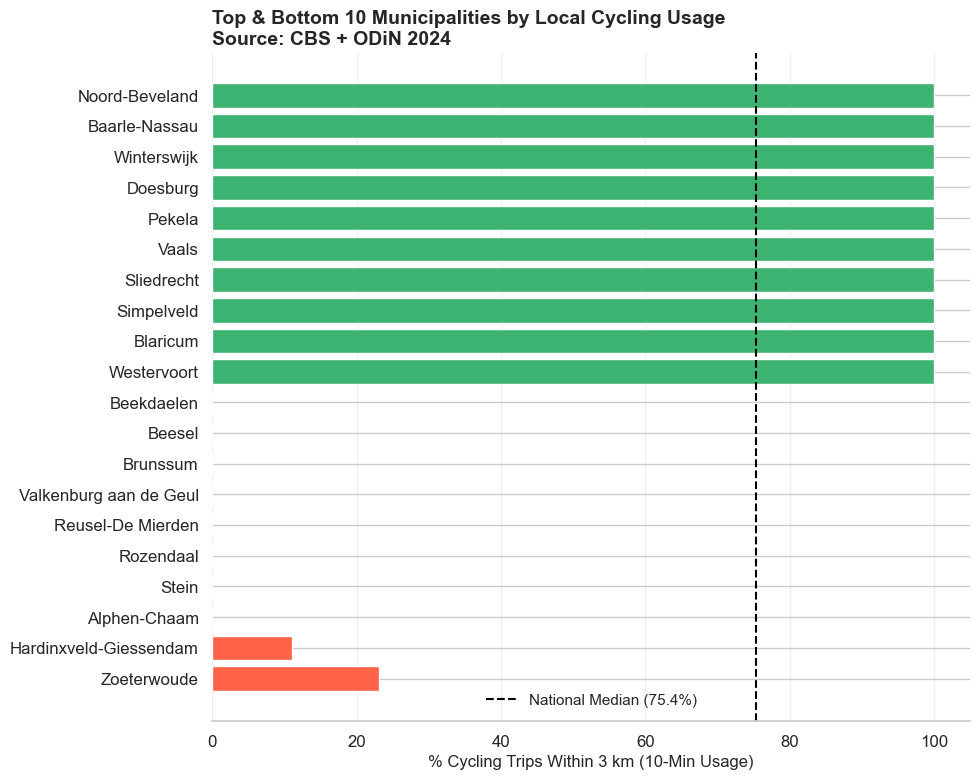

In [43]:
# Aggregate USAGE to the municipality level
mun_usage = (df_paired.groupby('gm_naam', observed=True)['pct_within_3km']
             .mean().sort_values())

# Extract Top 10 and Bottom 10
bottom10 = mun_usage.head(10)
top10    = mun_usage.tail(10).sort_values(ascending=False)
ranked_usage = pd.concat([top10, bottom10])

colors = ['mediumseagreen'] * 10 + ['tomato'] * 10 

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(ranked_usage.index, ranked_usage.values, color=colors, edgecolor='white')

# Add the national median line for benchmarking
national_median = mun_usage.median()
ax.axvline(national_median, ls='--', color='black', lw=1.5, 
           label=f'National Median ({national_median:.1f}%)')

ax.set_xlabel('% Cycling Trips Within 3 km (10-Min Usage)', fontsize=12)
ax.set_title('Top & Bottom 10 Municipalities by Local Cycling Usage\nSource: CBS + ODiN 2024',
             fontsize=14, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis() 

plt.tight_layout()
plt.savefig('fig_top_bottom_usage_mun.png', dpi=150)
plt.show()

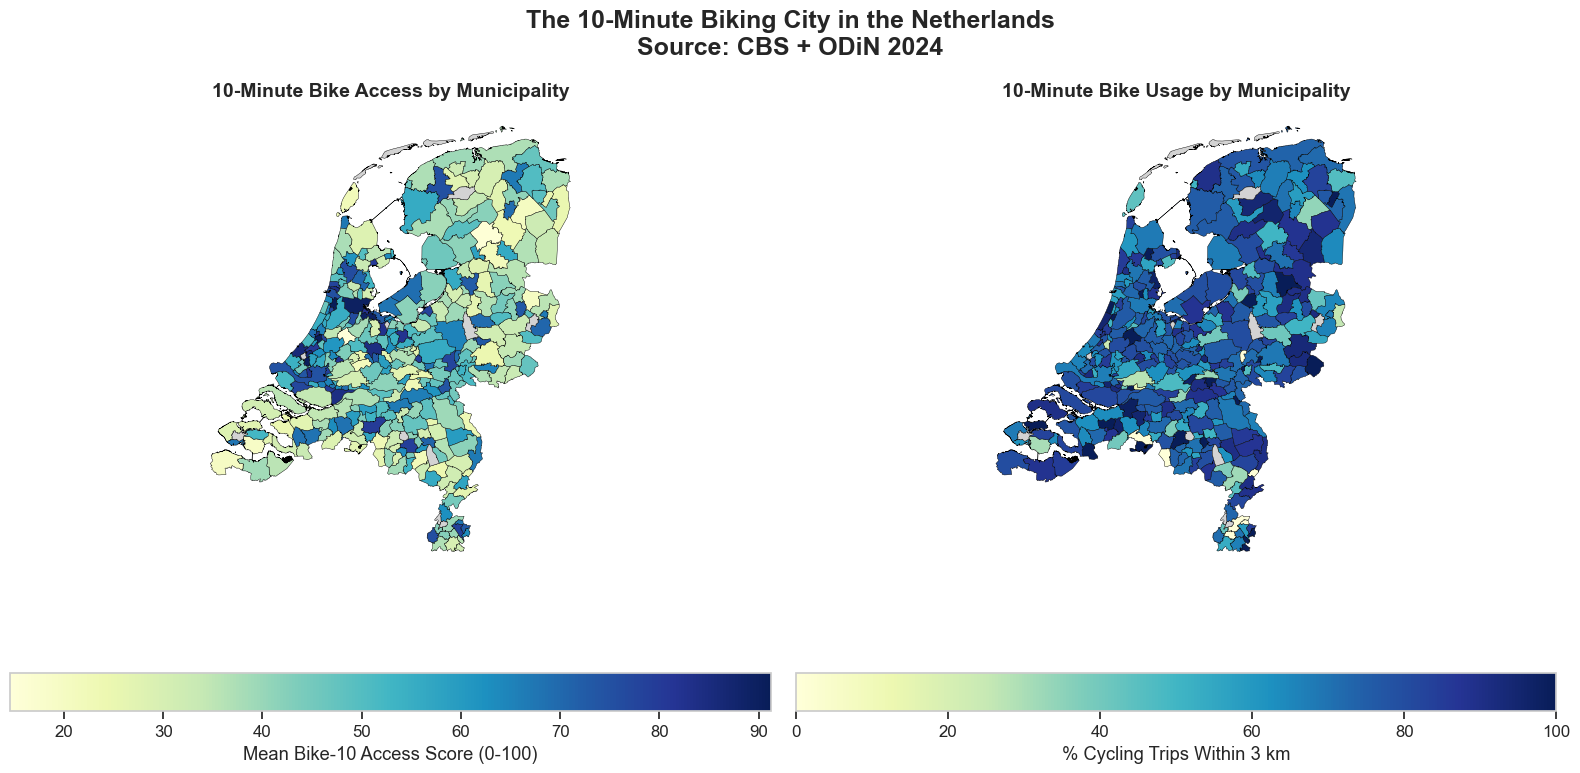

In [46]:
import geopandas as gpd

mun_macro = df_paired.groupby('gm_naam', observed=True).agg(
    mean_access=('bike10_weighted_score', 'mean'),
    mean_usage=('pct_within_3km', 'mean'),
    total_pop=('a_inw', 'sum')
).dropna().reset_index()

gdf_mun = gpd.read_file(r"C:\Users\20192436\Projects\DesignforAI\Data\CBS\wijkenbuurten_2025_v1.gpkg", layer='gemeenten')

# Filter out large bodies of water so the map looks like the actual Netherlands
if 'water' in gdf_mun.columns:
    gdf_mun = gdf_mun[gdf_mun['water'] == 'NEE']

# Merge data into the GeoDataFrame
gdf_mapped = gdf_mun.merge(mun_macro, left_on='gemeentenaam', right_on='gm_naam', how='left')

# Create a side-by-side map layout
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Map 1: Access Score (Blue/Green palette)
gdf_mapped.plot(column='mean_access', ax=axes[0], cmap='YlGnBu', 
                legend=True, legend_kwds={'label': "Mean Bike-10 Access Score (0-100)", 'orientation': "horizontal"},
                missing_kwds={'color': 'lightgrey', 'label': 'No Data'}, 
                edgecolor='black', linewidth=0.3) # Darker, thinner borders look professional

axes[0].set_title('10-Minute Bike Access by Municipality', fontsize=14, fontweight='bold')
axes[0].axis('off') # Hides the latitude/longitude axes

# Map 2: Usage Percentage (Red/Yellow/Green palette)
gdf_mapped.plot(column='mean_usage', ax=axes[1], cmap='YlGnBu', 
                legend=True, legend_kwds={'label': "% Cycling Trips Within 3 km", 'orientation': "horizontal"},
                missing_kwds={'color': 'lightgrey'}, 
                edgecolor='black', linewidth=0.3)

axes[1].set_title('10-Minute Bike Usage by Municipality', fontsize=14, fontweight='bold')
axes[1].axis('off')

fig.suptitle('The 10-Minute Biking City in the Netherlands\nSource: CBS + ODiN 2024', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('fig_geopandas_maps_cbs.png', dpi=300, bbox_inches='tight') 
plt.show()

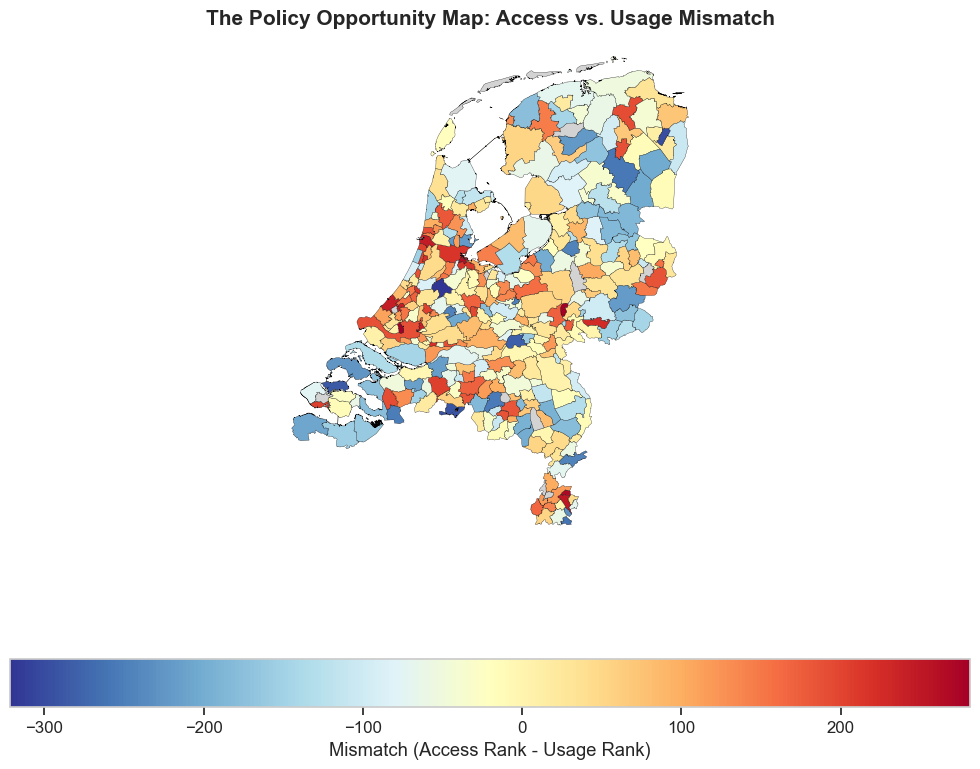

In [47]:
# Rank both variables from 1 to N (so they are on the exact same scale)
mun_macro['access_rank'] = mun_macro['mean_access'].rank()
mun_macro['usage_rank'] = mun_macro['mean_usage'].rank()

#Calculate the mismatch
# Positive gap = High Access but Low Usage (Underperforming)
# Negative gap = Low Access but High Usage (Overperforming)
mun_macro['mismatch_gap'] = mun_macro['access_rank'] - mun_macro['usage_rank']

# Merge with GeoDataFrame
gdf_mismatch = gdf_mun.merge(mun_macro, left_on='gemeentenaam', right_on='gm_naam', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Blue = Cycling Outperforms Access | Red = Access Outperforms Cycling
gdf_mismatch.plot(column='mismatch_gap', ax=ax, cmap='RdYlBu_r', 
                  legend=True, legend_kwds={'label': "Mismatch (Access Rank - Usage Rank)", 'orientation': "horizontal"},
                  missing_kwds={'color': 'lightgrey'}, edgecolor='black', linewidth=0.2)

ax.set_title('The Policy Opportunity Map: Access vs. Usage Mismatch', fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_mismatch_map.png', dpi=300)
plt.show()

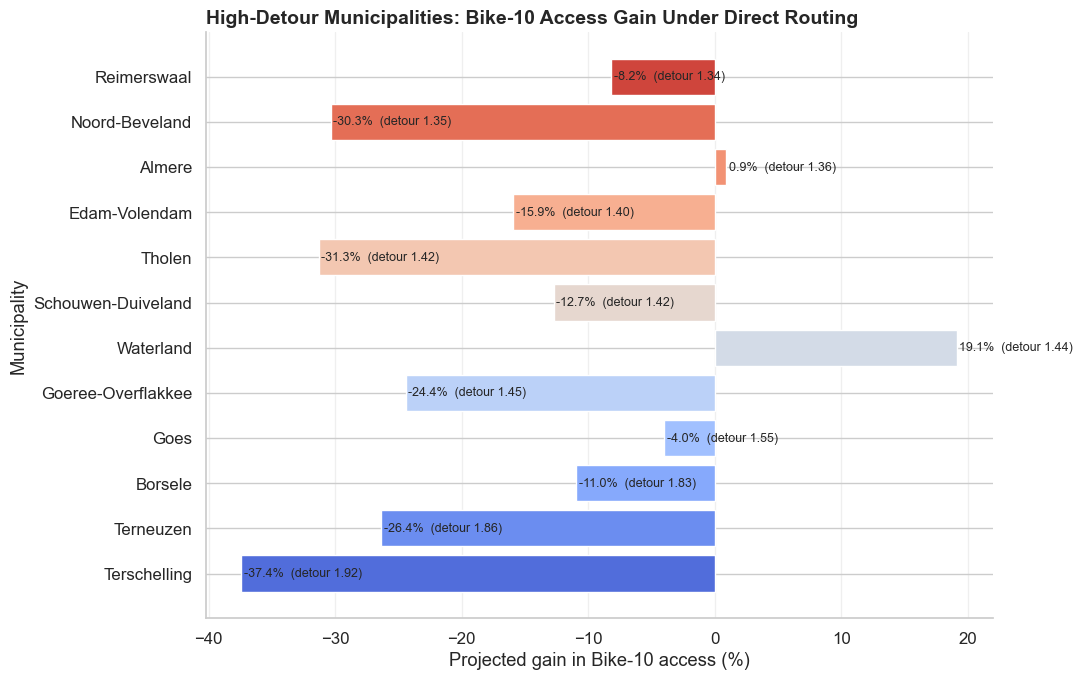

In [48]:
# Compare current bike-10 access with a direct-routing scenario
# Percent gain if detour rates could be reduced to straight-line routing

df_access['bike10_direct_gain_pct'] = np.where(
    df_access['bike10_weighted_score'] > 0,
    (df_access['bike10_direct_weighted_score'] - df_access['bike10_weighted_score'])
    / df_access['bike10_weighted_score'] * 100,
    np.nan
)

# Municipality-level summary for high-detour areas
mun_detour = (
    df_access.groupby('gm_naam', observed=True)
    .agg(
        mean_detour=('bike_detour_rate', 'mean'),
        mean_gain=('bike10_direct_gain_pct', 'mean'),
        n_buurten=('buurt_key', 'size')
    )
    .dropna()
    .query('n_buurten >= 5')
    .sort_values('mean_detour', ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('coolwarm', len(mun_detour))
bars = ax.barh(mun_detour.index, mun_detour['mean_gain'], color=colors, edgecolor='white')
for bar, detour in zip(bars, mun_detour['mean_detour']):
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}%  (detour {detour:.2f})', va='center', fontsize=9)

ax.set_xlabel('Projected gain in Bike-10 access (%)')
ax.set_title('High-Detour Municipalities: Bike-10 Access Gain Under Direct Routing', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('Municipality')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_direct_routing_bike_gain.png', dpi=150)
plt.show()


In [49]:
# 

In [50]:
# DEBUG: Analyze negative gains in detail
print("=== NEGATIVE GAINS ANALYSIS ===\n")

# Check available columns first
print("Available columns in df_access:")
print(df_access.columns.tolist()[:20])  # First 20 columns
print(f"Total columns: {len(df_access.columns)}\n")

# 1. How many neighborhoods have negative gains?
negative_gains = df_access[df_access['bike10_direct_gain_pct'] < 0]
print(f"Neighborhoods with NEGATIVE gains: {len(negative_gains)} / {len(df_access)} ({len(negative_gains)/len(df_access)*100:.1f}%)")
print(f"Neighborhoods with POSITIVE gains: {len(df_access[df_access['bike10_direct_gain_pct'] > 0])} / {len(df_access)}")

# 2. Distribution of gain percentages
print(f"\nGain statistics (%):")
print(f"  Min:     {df_access['bike10_direct_gain_pct'].min():.2f}%")
print(f"  25th %ile: {df_access['bike10_direct_gain_pct'].quantile(0.25):.2f}%")
print(f"  Median:   {df_access['bike10_direct_gain_pct'].median():.2f}%")
print(f"  75th %ile: {df_access['bike10_direct_gain_pct'].quantile(0.75):.2f}%")
print(f"  Max:      {df_access['bike10_direct_gain_pct'].max():.2f}%")

# 3. Look at worst negative cases (adjust columns as needed)
print("\n=== TOP 10 WORST NEGATIVE GAINS ===")
cols_available = ['gm_naam', 'bike10_weighted_score', 'bike10_direct_weighted_score', 'bike10_direct_gain_pct', 'bike_detour_rate']
cols_to_use = [col for col in cols_available if col in df_access.columns]
worst_negative = df_access[df_access['bike10_direct_gain_pct'] < 0].nsmallest(10, 'bike10_direct_gain_pct')[cols_to_use]
print(worst_negative.to_string())

# 4. Check if detour factors are reasonable (should be >= 1.0)
print(f"\n=== DETOUR FACTOR CHECK ===")
print(f"Detour factor range: {df_access['bike_detour_rate'].min():.3f} to {df_access['bike_detour_rate'].max():.3f}")
print(f"Detours < 1.0 (impossible): {(df_access['bike_detour_rate'] < 1.0).sum()} neighborhoods")
print(f"Detours exactly 1.0 (no detour): {(df_access['bike_detour_rate'] == 1.0).sum()} neighborhoods")

# 5. Compare direct vs smart scores for negative cases
if len(negative_gains) > 0:
    print(f"\n=== NEGATIVE GAINS DETAILED BREAKDOWN ===")
    print(f"For {len(negative_gains)} neighborhoods with negative gains:")
    print(f"  Mean smart score:  {negative_gains['bike10_weighted_score'].mean():.2f}")
    print(f"  Mean direct score: {negative_gains['bike10_direct_weighted_score'].mean():.2f}")
    print(f"  Mean detour rate:  {negative_gains['bike_detour_rate'].mean():.3f}")
    print(f"  Difference in means: {negative_gains['bike10_weighted_score'].mean() - negative_gains['bike10_direct_weighted_score'].mean():.2f}")


=== NEGATIVE GAINS ANALYSIS ===

Available columns in df_access:
['buurtcode', 'klasse_apotheek', 'klasse_basisschool', 'klasse_bushalte', 'klasse_fastfood', 'klasse_horeca', 'klasse_huisarts', 'klasse_kinderopvang', 'klasse_kledingwinkel', 'klasse_restaurant', 'klasse_sportterrein', 'klasse_supermarkt', 'klasse_treinstation', 'klasse_voortgezet_onderwijs', 'klasse_ziekenhuis', 'aantal_drinkwaterpunt', 'buurt_key', 'gwb_code_10', 'gwb_code_8', 'regio']
Total columns: 252

Neighborhoods with NEGATIVE gains: 6533 / 10493 (62.3%)
Neighborhoods with POSITIVE gains: 3933 / 10493

Gain statistics (%):
  Min:     -66.96%
  25th %ile: -15.60%
  Median:   -3.38%
  75th %ile: 3.80%
  Max:      310.52%

=== TOP 10 WORST NEGATIVE GAINS ===
               gm_naam  bike10_weighted_score  bike10_direct_weighted_score  bike10_direct_gain_pct  bike_detour_rate
7785            Tholen              32.435332                     10.715819              -66.962513          1.302410
7743         Terneuzen    

## DV3 - Social Exposure

Current status in this notebook:

- DV2 - Usage: complete
- DV2 - Access: complete
- DV2 - Access vs Usage: complete
- DV3 - Social exposure: extended below
- DV4 - Intervention map: still open

The goal of DV3 is to test whether the 3 km bike radius exposes residents to a broader socioeconomic mix than the 1.25 km walk radius.

In [51]:
# Build a destination-side socioeconomic profile from CBS neighbourhood data
income_order = ['Low', 'Low-mid', 'Middle', 'High-mid', 'High']
income_score_map = {'Low': 1, 'Low-mid': 2, 'Middle': 3, 'High-mid': 4, 'High': 5}
income_slug_map = {'Low': 'low', 'Low-mid': 'low_mid', 'Middle': 'middle', 'High-mid': 'high_mid', 'High': 'high'}

dest_profile = cbs_buurt[['buurt_key', 'gm_naam', 'a_inw', 'g_ink_pi']].copy()
dest_profile['a_inw'] = pd.to_numeric(dest_profile['a_inw'], errors='coerce')
dest_profile['g_ink_pi'] = pd.to_numeric(dest_profile['g_ink_pi'], errors='coerce')
dest_profile = dest_profile[dest_profile['a_inw'].fillna(0) > 0].copy()

income_codes = pd.qcut(dest_profile['g_ink_pi'], q=5, labels=False, duplicates='drop')
dest_profile['dest_income_group'] = income_codes.map({0: 'Low', 1: 'Low-mid', 2: 'Middle', 3: 'High-mid', 4: 'High'})
dest_profile['dest_income_score'] = dest_profile['dest_income_group'].map(income_score_map)
dest_profile = dest_profile.dropna(subset=['dest_income_group']).copy()

print(f'Destination buurten with valid income group: {len(dest_profile):,}')
display(dest_profile.head())

Destination buurten with valid income group: 1,950


,buurt_key,gm_naam,a_inw,g_ink_pi,dest_income_group,dest_income_score
3,00140000,Groningen,4745,26.6,Low,1.0
4,00140001,Groningen,6975,26.4,Low,1.0
5,00140002,Groningen,4400,26.4,Low,1.0
8,00140005,Groningen,6575,30.8,Low-mid,2.0
13,00140101,Groningen,5125,31.3,Low-mid,2.0


In [52]:
# Compute social exposure for walk15 and bike10 based on the reachable destination income mix
def compute_social_exposure(b2b_mask, label):
    reach = (
        buurt_to_buurt.loc[b2b_mask, ['ori_key', 'dest_key']]
        .merge(
            dest_profile[['buurt_key', 'a_inw', 'dest_income_group', 'dest_income_score']],
            left_on='dest_key',
            right_on='buurt_key',
            how='left'
        )
        .dropna(subset=['dest_income_group', 'a_inw'])
    )

    pop_by_group = (
        reach.groupby(['ori_key', 'dest_income_group'], observed=True)['a_inw']
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=income_order, fill_value=0)
    )

    reachable_pop = pop_by_group.sum(axis=1)
    share_df = pop_by_group.div(reachable_pop.replace(0, np.nan), axis=0)
    safe_shares = share_df.where(share_df > 0)
    shannon = -(safe_shares * np.log(safe_shares)).sum(axis=1).fillna(0)
    shannon_norm = shannon / np.log(len(income_order))
    effective_groups = np.exp(shannon)
    mean_income_score = share_df.mul(pd.Series(income_score_map), axis=1).sum(axis=1)

    out = pd.DataFrame({
        'buurt_key': pop_by_group.index,
        f'{label}_reachable_pop': reachable_pop.values,
        f'{label}_n_income_groups': (pop_by_group > 0).sum(axis=1).values,
        f'{label}_shannon': shannon.values,
        f'{label}_shannon_norm': shannon_norm.values,
        f'{label}_effective_income_groups': effective_groups.values,
        f'{label}_mean_income_score': mean_income_score.values,
    })

    for group in income_order:
        slug = income_slug_map[group]
        out[f'{label}_pop_{slug}'] = pop_by_group[group].values
        out[f'{label}_share_{slug}'] = share_df[group].fillna(0).values

    return out

walk_exposure = compute_social_exposure(buurt_to_buurt['walk_15min'], 'walk15')
bike_exposure = compute_social_exposure(buurt_to_buurt['bike_10min'], 'bike10')

df_dv3 = (
    df_access
    .merge(walk_exposure, on='buurt_key', how='left')
    .merge(bike_exposure, on='buurt_key', how='left')
)

df_dv3['diversity_gain_shannon'] = df_dv3['bike10_shannon_norm'] - df_dv3['walk15_shannon_norm']
df_dv3['diversity_gain_groups'] = df_dv3['bike10_n_income_groups'] - df_dv3['walk15_n_income_groups']
df_dv3['effective_group_gain'] = df_dv3['bike10_effective_income_groups'] - df_dv3['walk15_effective_income_groups']
df_dv3['reachable_pop_gain_pct'] = np.where(
    df_dv3['walk15_reachable_pop'] > 0,
    (df_dv3['bike10_reachable_pop'] - df_dv3['walk15_reachable_pop']) / df_dv3['walk15_reachable_pop'] * 100,
    np.nan
)
df_dv3['bike_expands_diversity'] = df_dv3['diversity_gain_shannon'] > 0

print(f'DV3 analysis sample: {len(df_dv3):,} origin buurten')
print(f"Origins with valid walk exposure: {df_dv3['walk15_shannon_norm'].notna().sum():,}")
print(f"Origins with valid bike exposure: {df_dv3['bike10_shannon_norm'].notna().sum():,}")

DV3 analysis sample: 10,493 origin buurten
Origins with valid walk exposure: 4,138
Origins with valid bike exposure: 6,546


In [53]:
# Direct summary for the RQ: does cycling expose residents to a broader socioeconomic mix?
summary_dv3 = pd.Series({
    'mean_walk15_diversity': df_dv3['walk15_shannon_norm'].mean(),
    'mean_bike10_diversity': df_dv3['bike10_shannon_norm'].mean(),
    'mean_diversity_gain': df_dv3['diversity_gain_shannon'].mean(),
    'median_diversity_gain': df_dv3['diversity_gain_shannon'].median(),
    'share_origins_with_higher_bike_diversity_pct': df_dv3['bike_expands_diversity'].mean() * 100,
    'mean_walk15_effective_groups': df_dv3['walk15_effective_income_groups'].mean(),
    'mean_bike10_effective_groups': df_dv3['bike10_effective_income_groups'].mean(),
    'mean_reachable_pop_gain_pct': df_dv3['reachable_pop_gain_pct'].mean(),
})

print('DV3 summary statistics:')
display(summary_dv3.to_frame('value'))

DV3 summary statistics:


,value
mean_walk15_diversity,0.172533
mean_bike10_diversity,0.390686
mean_diversity_gain,0.319530
median_diversity_gain,0.323251
share_origins_with_higher_bike_diversity_pct,28.399886
mean_walk15_effective_groups,1.433798
mean_bike10_effective_groups,2.130896
mean_reachable_pop_gain_pct,303.392927


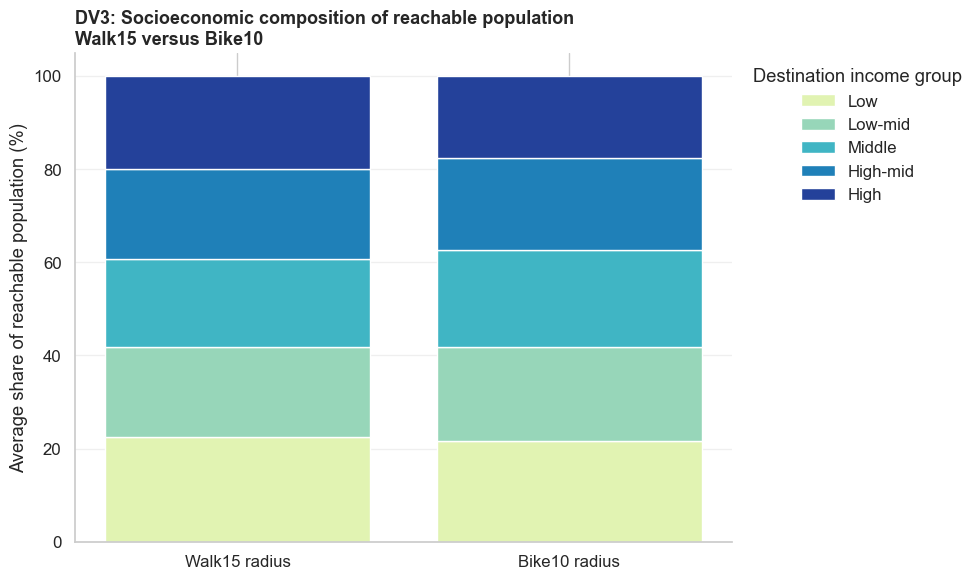

In [54]:
# Compare the average socioeconomic composition of the reachable population under walk15 and bike10
composition = pd.DataFrame({
    'walk15': [df_dv3[f'walk15_share_{income_slug_map[g]}'].mean() * 100 for g in income_order],
    'bike10': [df_dv3[f'bike10_share_{income_slug_map[g]}'].mean() * 100 for g in income_order],
}, index=income_order)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(2)
xlabels = ['Walk15 radius', 'Bike10 radius']
palette = sns.color_palette('YlGnBu', len(income_order))

for color, group in zip(palette, income_order):
    values = composition.loc[group].values
    ax.bar(xlabels, values, bottom=bottom, label=group, color=color, edgecolor='white')
    bottom = bottom + values

ax.set_ylabel('Average share of reachable population (%)')
ax.set_title('DV3: Socioeconomic composition of reachable population\nWalk15 versus Bike10', fontsize=13, fontweight='bold', loc='left')
ax.legend(title='Destination income group', bbox_to_anchor=(1.01, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_dv3_reachable_income_mix.png', dpi=150)
plt.show()

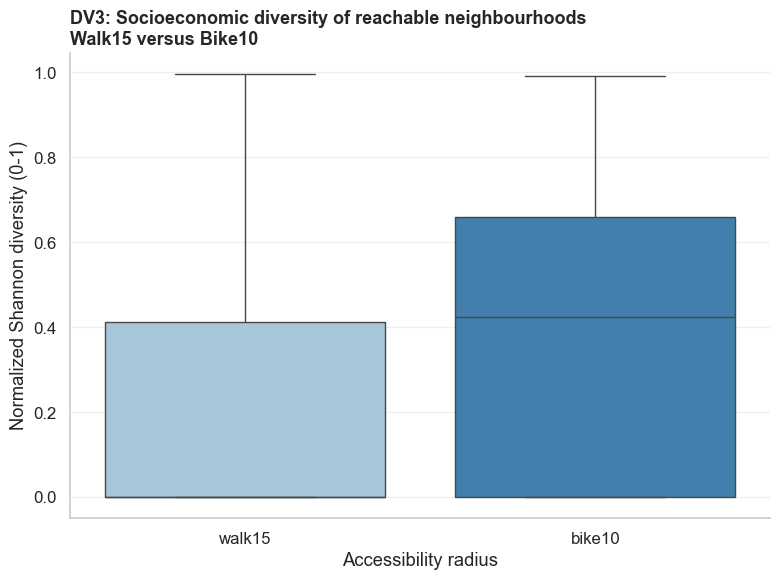

In [55]:
# Compare the diversity distribution directly between walk15 and bike10
div_long = pd.DataFrame({
    'walk15': df_dv3['walk15_shannon_norm'],
    'bike10': df_dv3['bike10_shannon_norm'],
}).melt(var_name='mode', value_name='diversity')

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=div_long, x='mode', y='diversity', hue='mode', palette=['#9ecae1', '#3182bd'], ax=ax)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_xlabel('Accessibility radius')
ax.set_ylabel('Normalized Shannon diversity (0-1)')
ax.set_title('DV3: Socioeconomic diversity of reachable neighbourhoods\nWalk15 versus Bike10', fontsize=13, fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_dv3_diversity_walk_vs_bike.png', dpi=150)
plt.show()

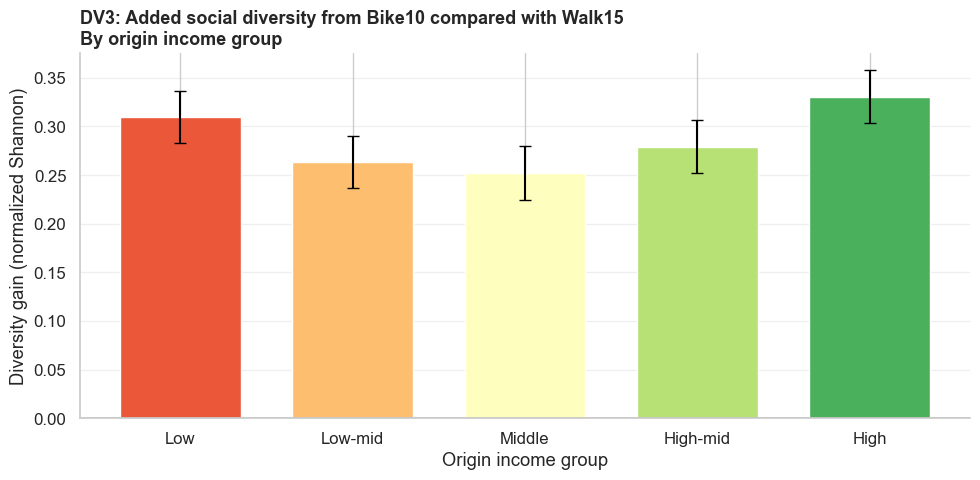

In [56]:
# Does cycling add more social exposure for some origin income groups than for others?
gain_by_income = (
    df_dv3.groupby('income_decile', observed=True)['diversity_gain_shannon']
    .agg(['mean', 'sem'])
    .reset_index()
)
gain_by_income['ci95'] = gain_by_income['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gain_by_income['income_decile'], gain_by_income['mean'], color=sns.color_palette('RdYlGn', len(gain_by_income)), edgecolor='white', width=0.7)
ax.errorbar(gain_by_income['income_decile'], gain_by_income['mean'], yerr=gain_by_income['ci95'], fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', lw=1)
ax.set_title('DV3: Added social diversity from Bike10 compared with Walk15\nBy origin income group', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Origin income group')
ax.set_ylabel('Diversity gain (normalized Shannon)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_dv3_gain_by_origin_income.png', dpi=150)
plt.show()

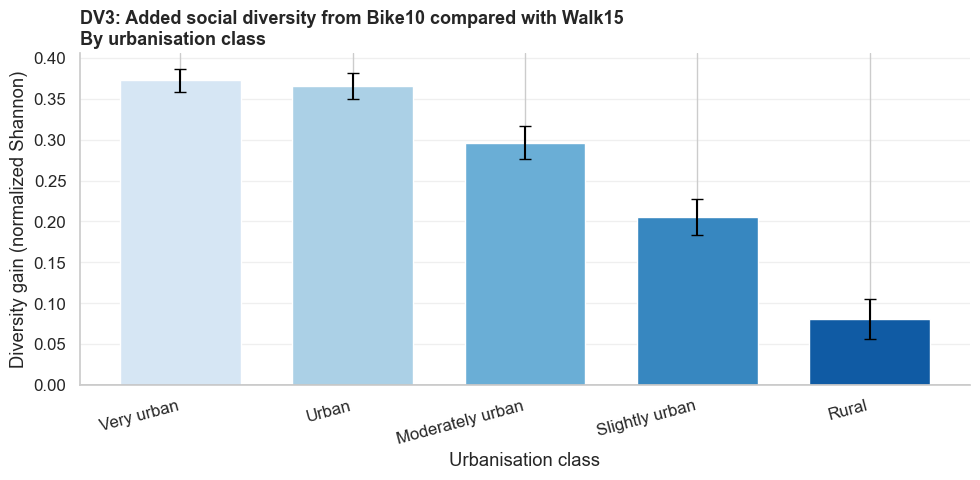

In [57]:
# Compare the diversity gain across urbanisation classes
urban_gain = (
    df_dv3.groupby('stedelijkheid_label', observed=True)['diversity_gain_shannon']
    .agg(['mean', 'sem'])
    .reset_index()
)
urban_order = ['Very urban', 'Urban', 'Moderately urban', 'Slightly urban', 'Rural']
urban_gain['stedelijkheid_label'] = pd.Categorical(urban_gain['stedelijkheid_label'], categories=urban_order, ordered=True)
urban_gain = urban_gain.sort_values('stedelijkheid_label')
urban_gain['ci95'] = urban_gain['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(urban_gain['stedelijkheid_label'], urban_gain['mean'], color=sns.color_palette('Blues', len(urban_gain)), edgecolor='white', width=0.7)
ax.errorbar(urban_gain['stedelijkheid_label'], urban_gain['mean'], yerr=urban_gain['ci95'], fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', lw=1)
ax.set_title('DV3: Added social diversity from Bike10 compared with Walk15\nBy urbanisation class', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation class')
ax.set_ylabel('Diversity gain (normalized Shannon)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig_dv3_gain_by_urbanity.png', dpi=150)
plt.show()

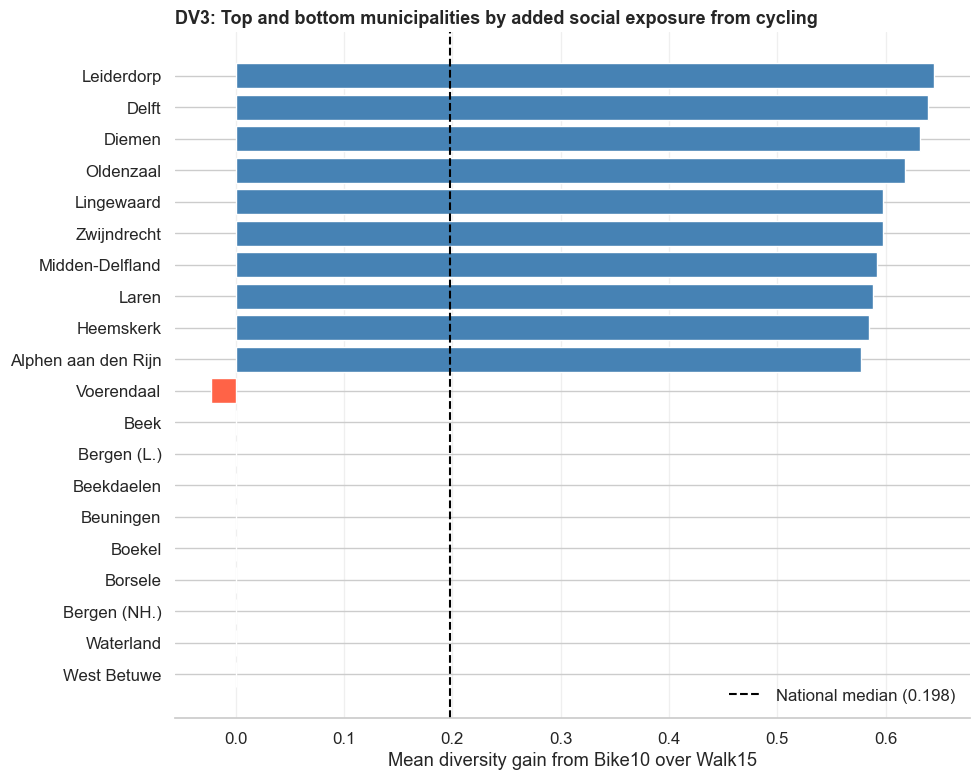

In [58]:
# Rank municipalities by how much cycling expands socioeconomic exposure beyond walking
mun_dv3 = (
    df_dv3.groupby('gm_naam', observed=True)
    .agg(
        mean_walk_diversity=('walk15_shannon_norm', 'mean'),
        mean_bike_diversity=('bike10_shannon_norm', 'mean'),
        mean_diversity_gain=('diversity_gain_shannon', 'mean'),
        total_pop=('a_inw', 'sum'),
        n_buurten=('buurt_key', 'size')
    )
    .dropna()
    .query('n_buurten >= 5')
)

rank_gain = mun_dv3['mean_diversity_gain'].sort_values()
bottom10 = rank_gain.head(10)
top10 = rank_gain.tail(10).sort_values(ascending=False)
ranked = pd.concat([top10, bottom10])
colors = ['steelblue'] * len(top10) + ['tomato'] * len(bottom10)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(ranked.index, ranked.values, color=colors, edgecolor='white')
ax.axvline(rank_gain.median(), ls='--', color='black', lw=1.5, label=f'National median ({rank_gain.median():.3f})')
ax.set_xlabel('Mean diversity gain from Bike10 over Walk15')
ax.set_title('DV3: Top and bottom municipalities by added social exposure from cycling', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_dv3_municipality_social_exposure_gain.png', dpi=150)
plt.show()